<a href="https://colab.research.google.com/github/Abdulgafar007/pywt/blob/main/Another_copy_of_Unified_Publication_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy pandas matplotlib scipy scikit-learn PyEMD pykalman statsmodels
!pip install EMD-signal PyWavelets vmdpy
!pip install numpy pandas matplotlib scipy scikit-learn PyEMD pykalman statsmodels
!pip install PyEMD vmdpy numpy pandas matplotlib scipy
!pip install PyEMD
!pip install EMD-signal PyWavelets vmdpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.1/252.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.1 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Successfu

In [ ]:
!pip install PyTorch
!pip install nolds

  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for PyTorch
  Running setup.py clean for PyTorch
Failed to build PyTorch
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (PyTorch)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.7/225.7 kB 4.1 MB/s eta 0:00:00


**PreScreen and 5 Criteria-Final Final**

In [ ]:
# @title

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.stats import entropy as scipy_entropy, linregress
from itertools import chain, combinations
import time
from PyEMD import EEMD
from vmdpy import VMD
from nolds import sampen

# ─────────────────────────────────────────────────────────────────────────────
# Shared utilities
# ─────────────────────────────────────────────────────────────────────────────

def powerset(iterable):
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(1, len(s)+1))

def weighted_median_filter(signal, kernel_size=7, weights=None):
    if weights is None:
        weights = np.ones(kernel_size, dtype=int)
    weights = np.array(weights, dtype=int)
    pad    = kernel_size // 2
    padded = np.pad(signal, pad, mode="edge")
    out    = np.empty_like(signal, dtype=float)
    for i in range(len(signal)):
        window = padded[i:i+kernel_size]
        out[i] = np.median(np.repeat(window, weights))
    return out

def nse(y_true, y_pred):
    denom = np.sum((y_true - np.mean(y_true)) ** 2)
    if denom <= 0:
        return -np.inf
    return 1 - np.sum((y_true - y_pred) ** 2) / denom

def compute_shannon_entropy(x, bins=None):
    x = np.asarray(x)
    if bins is None:
        bins = max(10, int(np.sqrt(len(x))))   # adaptive binning
    hist, _ = np.histogram(x, bins=bins, density=True)
    hist = hist[hist > 0]
    return scipy_entropy(hist) if hist.size else 0.0

def compute_sample_entropy(x):
    x = np.asarray(x)
    if x.size < 20 or np.allclose(np.std(x), 0):
        return np.nan
    return sampen(x, emb_dim=2, tolerance=0.1 * np.std(x))

def snr_db(y, yhat):
    sp  = np.mean(y ** 2)           + 1e-12
    npw = np.mean((y - yhat) ** 2)  + 1e-12
    return 10 * np.log10(sp / npw)

def jsd_divergence(p_data, q_data, bins=50):
    p, edges = np.histogram(p_data, bins=bins, density=True)
    q, _     = np.histogram(q_data, bins=edges, density=True)
    p += 1e-12;  q += 1e-12
    m  = 0.5 * (p + q)
    return 0.5 * (scipy_entropy(p, m) + scipy_entropy(q, m))

def r2_linregress(x, y):
    x = np.asarray(x); y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return np.nan
    _, _, r_value, _, _ = linregress(x[mask], y[mask])
    return r_value ** 2

# ─────────────────────────────────────────────────────────────────────────────
# VMD mode alignment (Hungarian algorithm)
# ─────────────────────────────────────────────────────────────────────────────

def _align_modes(reference, candidate):
    """
    Align candidate VMD modes to reference ordering using maximum-correlation
    matching (Hungarian algorithm).  Prevents mode-permutation artefacts when
    averaging across ensemble runs.
    """
    from scipy.optimize import linear_sum_assignment
    K       = reference.shape[0]
    min_len = min(reference.shape[1], candidate.shape[1])
    corr    = np.abs(np.corrcoef(
        reference[:, :min_len], candidate[:, :min_len]
    )[:K, K:])
    _, col_ind = linear_sum_assignment(-corr)
    return candidate[col_ind]

# ─────────────────────────────────────────────────────────────────────────────
# Two-stage evaluator
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_subset(recon, raw_signal, energies, sel,
                    normalized_energy, correlations, sigH,
                    # Pre-screen thresholds
                    energy_threshold=0.01,
                    corr_threshold=0.10,
                    # Voting thresholds
                    entropy_tol=0.20,
                    jsd_threshold=0.50,
                    neg_frac_limit=0.05,
                    neg_mag_limit=0.02,
                    votes_required=4):
    """
    Two-stage evaluation for a candidate IMF/mode subset.

    Stage 1 — Pre-screen (hard physical constraints)
    ─────────────────────────────────────────────────
    P1. Every selected mode must contribute > energy_threshold of total energy.
        Rationale: modes below 1% energy are noise or numerical artefacts.
    P2. Every selected mode must have Pearson r > corr_threshold with the
        pre-filtered signal.
        Rationale: modes with near-zero correlation to the signal carry no
        meaningful turbidity information (Zhang et al., 2008).

    Stage 2 — Voting (graded quality, majority required)
    ─────────────────────────────────────────────────────
    c1. Shannon entropy of reconstruction within ±entropy_tol of raw signal
        entropy (symmetric tolerance preserves informational complexity).
    c2. NSE > adaptive threshold: 0.3 if signal CV > 1.0, else 0.5.
        (Moriasi et al., 2007; relaxed for high-variability storms.)
    c3. JSD(raw, recon) < jsd_threshold.
        (Distributional similarity; JSD bounded [0,1].)
    c4. Non-negativity: neg_frac < neg_frac_limit AND
        neg_magnitude < neg_mag_limit × mean(raw).
        (Soft physical constraint; turbidity non-negative.)
    c5. Pearson r(raw, recon) > 0.5 at reconstruction level.
        (Linear agreement of full reconstruction, not per-mode.)

    Returns
    -------
    pre_passed : bool   — True if both pre-screens pass
    vote_passed: bool   — True if pre_passed AND votes_met >= votes_required
    votes_met  : int    — number of voting criteria satisfied (0–5)
    detail     : dict   — all computed values and flags for logging/CSV
    """

    # ── Pre-screen ────────────────────────────────────────────────────────────
    p1 = bool(np.all(normalized_energy[list(sel)] > energy_threshold))
    p2 = bool(np.all(np.array(correlations)[list(sel)] > corr_threshold))
    pre_passed = p1 and p2

    # ── Shared quantities ─────────────────────────────────────────────────────
    entropy_sel  = compute_shannon_entropy(recon)
    nse_sel      = nse(raw_signal, recon)
    jsd_sel      = jsd_divergence(raw_signal, recon)
    recon_corr   = float(np.corrcoef(raw_signal, recon)[0, 1])

    neg_vals     = recon[recon < 0]
    neg_frac     = len(neg_vals) / len(recon)
    neg_mag      = (float(np.abs(neg_vals).mean()) /
                    (float(np.mean(raw_signal)) + 1e-12)) if len(neg_vals) > 0 else 0.0

    signal_cv    = float(np.std(raw_signal)) / (float(np.mean(raw_signal)) + 1e-12)
    nse_thresh   = 0.3 if signal_cv > 1.0 else 0.5

    if np.isfinite(sigH) and sigH > 0:
        entropy_ratio = abs(entropy_sel - sigH) / sigH
        c1 = bool(entropy_ratio <= entropy_tol)
    else:
        entropy_ratio = np.nan
        c1 = False

    c2 = bool(nse_sel      > nse_thresh)
    c3 = bool(jsd_sel      < jsd_threshold)
    c4 = bool(neg_frac     < neg_frac_limit and neg_mag < neg_mag_limit)
    c5 = bool(recon_corr   > 0.5)

    votes_met   = sum([c1, c2, c3, c4, c5])
    vote_passed = pre_passed and (votes_met >= votes_required)

    detail = {
        # Pre-screen flags
        "p1_energy":       int(p1),
        "p2_imf_corr":     int(p2),
        "pre_passed":      int(pre_passed),
        # Voting values
        "entropy_sel":     round(entropy_sel,   4),
        "entropy_ratio":   round(entropy_ratio, 4) if np.isfinite(entropy_ratio) else np.nan,
        "nse_sel":         round(nse_sel,        4),
        "nse_threshold":   round(nse_thresh,     4),
        "jsd_sel":         round(jsd_sel,        4),
        "recon_corr":      round(recon_corr,     4),
        "neg_frac":        round(neg_frac,       4),
        "neg_mag":         round(neg_mag,        4),
        # Voting flags (int for easy CSV averaging)
        "c1_entropy":      int(c1),
        "c2_nse":          int(c2),
        "c3_jsd":          int(c3),
        "c4_nonneg":       int(c4),
        "c5_recon_corr":   int(c5),
        "votes_met":       votes_met,
        "vote_passed":     int(vote_passed),
    }
    return pre_passed, vote_passed, detail

# ─────────────────────────────────────────────────────────────────────────────
# Logging helper
# ─────────────────────────────────────────────────────────────────────────────

def _print_detail(label, d, subset):
    print(f"\n  {label}  —  subset {subset}  |  "
          f"pre={'✅' if d['pre_passed'] else '❌'}  "
          f"votes={d['votes_met']}/5  "
          f"{'✅ accepted' if d['vote_passed'] else '❌ rejected'}")
    print(f"    {'Pre-screen':<28} P1 energy={'✅' if d['p1_energy'] else '❌'}  "
          f"P2 IMF-corr={'✅' if d['p2_imf_corr'] else '❌'}")
    print(f"    {'c1 Entropy (±20%)':<28} ratio={d['entropy_ratio']:.4f}  "
          f"{'✅' if d['c1_entropy'] else '❌'}")
    print(f"    {'c2 NSE':<28} {d['nse_sel']:.4f} > {d['nse_threshold']}  "
          f"{'✅' if d['c2_nse'] else '❌'}  (adaptive)")
    print(f"    {'c3 JSD':<28} {d['jsd_sel']:.4f} < 0.5  "
          f"{'✅' if d['c3_jsd'] else '❌'}")
    print(f"    {'c4 Non-negativity':<28} frac={d['neg_frac']:.4f} mag={d['neg_mag']:.4f}  "
          f"{'✅' if d['c4_nonneg'] else '❌'}")
    print(f"    {'c5 Recon correlation':<28} r={d['recon_corr']:.4f} > 0.5  "
          f"{'✅' if d['c5_recon_corr'] else '❌'}")

# ─────────────────────────────────────────────────────────────────────────────
# EEMD block
# ─────────────────────────────────────────────────────────────────────────────

def eemd_run(filtered_signal, raw_signal, label, verbose=True):
    """
    WMF-EEMD decomposition with two-stage pre-screen + 4-of-5 voting.

    Parameters
    ----------
    filtered_signal : np.array  WMF-filtered turbidity
    raw_signal      : np.array  original (unfiltered) turbidity
    label           : str       identifier for print output
    verbose         : bool      print per-storm detail table

    Returns
    -------
    dict with keys:
        final      — selected reconstruction
        recon_all  — sum of all IMFs (L2 level)
        used       — list of selected IMF indices
        elapsed    — decomposition time (s)
        nse_all    — NSE of all-IMF reconstruction vs raw
        diagnostics — detail dict of best qualifying subset (None if fallback)
        pre_fail_count  — subsets rejected at pre-screen stage
        vote_fail_count — subsets passing pre-screen but failing voting
    """
    t     = np.arange(len(filtered_signal))
    eemd  = EEMD()
    eemd.noise_seed(42)
    eemd.trials      = 100
    eemd.noise_width = 0.1

    start   = time.time()
    imfs    = eemd.eemd(filtered_signal, t)
    elapsed = time.time() - start

    energies          = np.array([np.sum(imf**2) for imf in imfs])
    normalized_energy = energies / np.sum(energies)
    correlations      = np.array([np.corrcoef(filtered_signal, imf)[0, 1]
                                   for imf in imfs])
    recon_all         = np.sum(imfs, axis=0)
    sigH              = compute_shannon_entropy(raw_signal)

    best_subset    = None
    best_jsd       = np.inf
    best_recon     = None
    best_nse_val   = -np.inf
    best_votes     = 0
    best_detail    = None
    pre_fail_count = 0
    vote_fail_count= 0

    for subset in powerset(range(imfs.shape[0])):
        sel   = list(subset)
        recon = np.sum(imfs[sel, :], axis=0)

        pre_ok, vote_ok, detail = evaluate_subset(
            recon, raw_signal, energies, sel,
            normalized_energy, correlations, sigH
        )

        if not pre_ok:
            pre_fail_count += 1
            continue

        if not vote_ok:
            vote_fail_count += 1
            continue

        if detail["jsd_sel"] < best_jsd:
            best_jsd    = detail["jsd_sel"]
            best_subset = sel
            best_recon  = recon
            best_nse_val= detail["nse_sel"]
            best_votes  = detail["votes_met"]
            best_detail = detail

    nse_all = nse(raw_signal, recon_all)

    if best_subset is not None:
        # Secondary fallback: revert if selected NSE is meaningfully worse
        if best_nse_val < 0.90 * nse_all and nse_all > 0:

            print(f"\n⚠️  {label}: selected NSE ({best_nse_val:.4f}) > 0.05 below "
                  f"all-IMFs NSE ({nse_all:.4f}) → reverting to all IMFs")
            final  = recon_all
            used   = list(range(imfs.shape[0]))
            detail = None
        else:
            if verbose:
                _print_detail(label, best_detail, best_subset)
            final  = best_recon
            used   = best_subset
            detail = best_detail
    else:
        print(f"\n⚠️  {label}: no subset passed pre-screen + voting → using all IMFs  "
              f"(pre-fails={pre_fail_count}, vote-fails={vote_fail_count})")
        final  = recon_all
        used   = list(range(imfs.shape[0]))
        detail = None

    return {
        "final":           final,
        "recon_all":       recon_all,
        "used":            used,
        "elapsed":         elapsed,
        "nse_all":         nse_all,
        "diagnostics":     detail,
        "pre_fail_count":  pre_fail_count,
        "vote_fail_count": vote_fail_count,
        "n_imfs":          imfs.shape[0],
    }

# ─────────────────────────────────────────────────────────────────────────────
# VMD block
# ─────────────────────────────────────────────────────────────────────────────

def vmd_run(filtered_signal, raw_signal, label,
            K=6, alpha=2000, tol=1e-7, n_runs=10, verbose=True):
    """
    WMF-VMD decomposition with two-stage pre-screen + 4-of-5 voting.

    Ensemble approach
    -----------------
    Run VMD n_runs times with small noise perturbation (1% std).
    Modes aligned across runs via Hungarian matching before averaging
    to prevent mode-permutation artefacts.

    Parameters and returns mirror eemd_run.
    """
    np.random.seed(42)
    all_modes = []
    start     = time.time()

    for _ in range(n_runs):
        noisy = filtered_signal + np.random.normal(
            0, 0.01 * np.std(filtered_signal), len(filtered_signal)
        )
        u, _, _ = VMD(noisy, alpha=alpha, tau=0, K=K, DC=0, init=1, tol=tol)
        all_modes.append(u)

    elapsed = time.time() - start

    # Align before averaging
    reference = all_modes[0]
    aligned   = [reference]
    for candidate in all_modes[1:]:
        aligned.append(_align_modes(reference, candidate))

    min_len           = min(u.shape[1] for u in aligned)
    imfs              = np.mean([u[:, :min_len] for u in aligned], axis=0)
    raw_trim          = raw_signal[:min_len]
    filt_trim         = filtered_signal[:min_len]

    energies          = np.array([np.sum(m**2) for m in imfs])
    normalized_energy = energies / np.sum(energies)
    correlations      = np.array([np.corrcoef(filt_trim, imfs[i, :])[0, 1]
                                   for i in range(imfs.shape[0])])
    recon_all         = np.sum(imfs, axis=0)
    sigH              = compute_shannon_entropy(raw_trim)

    best_subset    = None
    best_jsd       = np.inf
    best_recon     = None
    best_nse_val   = -np.inf
    best_votes     = 0
    best_detail    = None
    pre_fail_count = 0
    vote_fail_count= 0

    for subset in powerset(range(imfs.shape[0])):
        sel   = list(subset)
        recon = np.sum(imfs[sel, :], axis=0)

        pre_ok, vote_ok, detail = evaluate_subset(
            recon, raw_trim, energies, sel,
            normalized_energy, correlations, sigH
        )

        if not pre_ok:
            pre_fail_count += 1
            continue

        if not vote_ok:
            vote_fail_count += 1
            continue

        if detail["jsd_sel"] < best_jsd:
            best_jsd    = detail["jsd_sel"]
            best_subset = sel
            best_recon  = recon
            best_nse_val= detail["nse_sel"]
            best_votes  = detail["votes_met"]
            best_detail = detail

    nse_all = nse(raw_trim, recon_all)

    if best_subset is not None:
        if best_nse_val < 0.90 * nse_all and nse_all > 0:

            print(f"\n⚠️  {label}: selected NSE ({best_nse_val:.4f}) > 0.05 below "
                  f"all-modes NSE ({nse_all:.4f}) → reverting to all modes")
            final  = recon_all
            used   = list(range(imfs.shape[0]))
            detail = None
        else:
            if verbose:
                _print_detail(label, best_detail, best_subset)
            final  = best_recon
            used   = best_subset
            detail = best_detail
    else:
        print(f"\n⚠️  {label}: no subset passed pre-screen + voting → using all modes  "
              f"(pre-fails={pre_fail_count}, vote-fails={vote_fail_count})")
        final  = recon_all
        used   = list(range(imfs.shape[0]))
        detail = None

    return {
        "final":           final,
        "recon_all":       recon_all,
        "used":            used,
        "elapsed":         elapsed,
        "trimmed_length":  min_len,
        "nse_all":         nse_all,
        "diagnostics":     detail,
        "pre_fail_count":  pre_fail_count,
        "vote_fail_count": vote_fail_count,
        "n_modes":         imfs.shape[0],
    }

# ─────────────────────────────────────────────────────────────────────────────
# Metrics helper
# ─────────────────────────────────────────────────────────────────────────────

def compute_metrics_block(signal, reconstruction, radar, mask):
    """
    Compute all performance metrics for one reconstruction level.
    R2  — reconstruction vs radar (water level), external physical reference.
    NSE, JSD, SNR — reconstruction vs raw turbidity signal.
    """
    n           = min(len(signal), len(reconstruction))
    y_true      = signal[:n];  y_pred = reconstruction[:n]
    valid_mask  = mask[:n] & np.isfinite(y_pred)
    radar_valid = radar[:n][valid_mask]
    return {
        "R2":         r2_linregress(y_pred[valid_mask], radar_valid),
        "NSE":        nse(y_true, y_pred),
        "JSD":        jsd_divergence(y_true, y_pred),
        "SNR":        snr_db(y_true, y_pred),
        "Mean":       float(np.mean(y_pred)),
        "Median":     float(np.median(y_pred)),
        "Peak":       float(np.max(y_pred)),
        "Shannon":    compute_shannon_entropy(y_pred),
        "Sample":     compute_sample_entropy(y_pred),
        "DataPoints": int(np.sum(valid_mask)),
    }

def _contrib(prefix, metrics):
    return {f"{prefix}_{k}": v for k, v in metrics.items()}

def _gain(new_m, base_m, metric):
    v_new  = new_m.get(metric, np.nan)
    v_base = base_m.get(metric, np.nan)
    if v_new is None or v_base is None:
        return np.nan
    try:
        return round(float(v_new) - float(v_base), 4)
    except Exception:
        return np.nan

# ─────────────────────────────────────────────────────────────────────────────
# Batch analysis
# ─────────────────────────────────────────────────────────────────────────────

def run_batch_analysis(
        date_config,
        save_name="All_Sites_Summary.csv",
        contribution_save="All_Sites_Contribution.csv",
        plot=True,
        plot_dir="unstable_storm_plots",
        verbose=True):
    """
    Run WMF-EEMD and WMF-VMD across all storms and files.

    Parameters
    ----------
    date_config : dict
        { file_path : [(start_date, end_date), ...], ... }
        Dates as strings parseable by pandas (e.g. '2023-12-09 00:00').

    save_name : str
        Main results CSV — one row per storm, L3 selected metrics +
        voting diagnostics.

    contribution_save : str
        Component contribution CSV — four reconstruction levels per storm:
          L0 Raw, L1 WMF, L2 EEMD/VMD all modes, L3 EEMD/VMD selected.
        Includes marginal gain columns for each step.

    verbose : bool
        If True, print per-storm criteria detail tables.

    Returns
    -------
    df_main    : pd.DataFrame   main results
    df_contrib : pd.DataFrame   component contribution
    """
    main_rows    = []
    contrib_rows = []
    storm_plot_data = []

    for file_path, date_pairs in date_config.items():
        print(f"\n\n{'='*60}")
        print(f"  File: {file_path}")
        print(f"{'='*60}")

        df = pd.read_csv(file_path, parse_dates=["datetime_et"])
        df["Turbidity"] = (
            df["Turbidity"]
            .interpolate().bfill().ffill()
        )
        radar = pd.to_numeric(
            df.get("Radar data", pd.Series(index=df.index, dtype=float)),
            errors="coerce"
        ).to_numpy()
        radar[(np.isclose(radar, 0, atol=1.0)) | (radar > 20)] = np.nan

        for (start_date, end_date) in date_pairs:
            print(f"\n→ {start_date}  to  {end_date}")

            sub = df[
                (df["datetime_et"] >= start_date) &
                (df["datetime_et"] <= end_date)
            ].copy()

            if sub.empty:
                print("  ⚠️  Empty period — skipped.")
                continue

            signal       = sub["Turbidity"].to_numpy(dtype=float)
            radar_sub    = radar[sub.index]
            mask         = np.isfinite(radar_sub)
            weights      = [1, 4, 7, 10, 7, 4, 1]
            wmf_filtered = weighted_median_filter(
                signal, kernel_size=7, weights=weights
            )

            # ── Decompose ─────────────────────────────────────────────────────
            eemd_wmf = eemd_run(wmf_filtered, signal, "WMF-EEMD", verbose=verbose)
            vmd_wmf  = vmd_run(wmf_filtered,  signal, "WMF-VMD",  verbose=verbose)

            # ── Component contribution (4 levels) ────────────────────────────
            n = min(
                len(signal), len(wmf_filtered),
                len(eemd_wmf["final"]), len(eemd_wmf["recon_all"]),
                len(vmd_wmf["final"]),  len(vmd_wmf["recon_all"]),
            )
            sig_t  = signal[:n];  wmf_t = wmf_filtered[:n]
            rad_t  = radar_sub[:n]
            msk_t  = mask[:n] & np.isfinite(rad_t)

            m_L0        = compute_metrics_block(sig_t, sig_t,                       rad_t, msk_t)
            m_L1        = compute_metrics_block(sig_t, wmf_t,                       rad_t, msk_t)
            m_L2_eemd   = compute_metrics_block(sig_t, eemd_wmf["recon_all"][:n],   rad_t, msk_t)
            m_L3_eemd   = compute_metrics_block(sig_t, eemd_wmf["final"][:n],       rad_t, msk_t)
            m_L2_vmd    = compute_metrics_block(sig_t, vmd_wmf["recon_all"][:n],    rad_t, msk_t)
            m_L3_vmd    = compute_metrics_block(sig_t, vmd_wmf["final"][:n],        rad_t, msk_t)

            # Print per-storm contribution table
            print(f"\n  {'─'*72}")
            print(f"  Component contribution — {start_date} → {end_date}")
            print(f"  {'Level':<32} {'R2':>8} {'NSE':>8} {'JSD':>8} "
                  f"{'SNR':>8} {'Peak':>10}")
            print(f"  {'─'*72}")
            for lname, m in [
                ("L0  Raw signal",             m_L0),
                ("L1  WMF only",               m_L1),
                ("L2  WMF + EEMD (all)",       m_L2_eemd),
                ("L3  WMF + EEMD (selected)",  m_L3_eemd),
                ("L2  WMF + VMD  (all)",       m_L2_vmd),
                ("L3  WMF + VMD  (selected)",  m_L3_vmd),
            ]:
                def _f(v):
                    return f"{v:.4f}" if v is not None and np.isfinite(v) else "N/A"
                print(f"  {lname:<32} {_f(m['R2']):>8} {_f(m['NSE']):>8} "
                      f"{_f(m['JSD']):>8} {_f(m['SNR']):>8} "
                      f"{m['Peak']:>10.2f}")

            # ── Diagnostics dicts ─────────────────────────────────────────────
            ed = eemd_wmf["diagnostics"] or {}
            vd = vmd_wmf["diagnostics"]  or {}

            # ── Main results record ───────────────────────────────────────────
            main_row = {
                "File":      file_path.split("/")[-1],
                "Start":     start_date,
                "End":       end_date,
                "N":         n,
                "Time_EEMD": round(eemd_wmf["elapsed"], 2),
                "Time_VMD":  round(vmd_wmf["elapsed"],  2),
                "N_IMFs":    eemd_wmf["n_imfs"],
                "N_Modes":   vmd_wmf["n_modes"],

                # Pre-screen rejection counts
                "EEMD_PreFail":  eemd_wmf["pre_fail_count"],
                "VMD_PreFail":   vmd_wmf["pre_fail_count"],
                "EEMD_VoteFail": eemd_wmf["vote_fail_count"],
                "VMD_VoteFail":  vmd_wmf["vote_fail_count"],

                # Votes met
                "VotesMet_EEMD": ed.get("votes_met",   "fallback"),
                "VotesMet_VMD":  vd.get("votes_met",   "fallback"),

                # Pre-screen flags — EEMD
                "EEMD_p1_energy":   ed.get("p1_energy"),
                "EEMD_p2_imf_corr": ed.get("p2_imf_corr"),

                # Voting flags — EEMD
                "EEMD_c1_entropy":  ed.get("c1_entropy"),
                "EEMD_c2_nse":      ed.get("c2_nse"),
                "EEMD_c3_jsd":      ed.get("c3_jsd"),
                "EEMD_c4_nonneg":   ed.get("c4_nonneg"),
                "EEMD_c5_recon_corr":ed.get("c5_recon_corr"),

                # Pre-screen flags — VMD
                "VMD_p1_energy":    vd.get("p1_energy"),
                "VMD_p2_imf_corr":  vd.get("p2_imf_corr"),

                # Voting flags — VMD
                "VMD_c1_entropy":   vd.get("c1_entropy"),
                "VMD_c2_nse":       vd.get("c2_nse"),
                "VMD_c3_jsd":       vd.get("c3_jsd"),
                "VMD_c4_nonneg":    vd.get("c4_nonneg"),
                "VMD_c5_recon_corr":vd.get("c5_recon_corr"),

                # L0 original
                "R2_Orig":      m_L0["R2"],
                "Mean_Orig":    m_L0["Mean"],
                "Median_Orig":  m_L0["Median"],
                "Peak_Orig":    m_L0["Peak"],
                "Shannon_Orig": m_L0["Shannon"],
                "Sample_Orig":  m_L0["Sample"],

                # L3 EEMD selected
                "R2_EEMD":      m_L3_eemd["R2"],
                "NSE_EEMD":     m_L3_eemd["NSE"],
                "JSD_EEMD":     m_L3_eemd["JSD"],
                "SNR_EEMD":     m_L3_eemd["SNR"],
                "Mean_EEMD":    m_L3_eemd["Mean"],
                "Median_EEMD":  m_L3_eemd["Median"],
                "Peak_EEMD":    m_L3_eemd["Peak"],
                "Shannon_EEMD": m_L3_eemd["Shannon"],
                "Sample_EEMD":  m_L3_eemd["Sample"],

                # L3 VMD selected
                "R2_VMD":       m_L3_vmd["R2"],
                "NSE_VMD":      m_L3_vmd["NSE"],
                "JSD_VMD":      m_L3_vmd["JSD"],
                "SNR_VMD":      m_L3_vmd["SNR"],
                "Mean_VMD":     m_L3_vmd["Mean"],
                "Median_VMD":   m_L3_vmd["Median"],
                "Peak_VMD":     m_L3_vmd["Peak"],
                "Shannon_VMD":  m_L3_vmd["Shannon"],
                "Sample_VMD":   m_L3_vmd["Sample"],
            }
            main_rows.append(main_row)

            # ── Contribution record ───────────────────────────────────────────
            contrib_row = {
                "File": file_path.split("/")[-1],
                "Start": start_date,
                "End": end_date,
                "N": n,
            }
            contrib_row.update(_contrib("L0_Raw",      m_L0))
            contrib_row.update(_contrib("L1_WMF",      m_L1))
            contrib_row.update(_contrib("L2_EEMD_All", m_L2_eemd))
            contrib_row.update(_contrib("L3_EEMD_Sel", m_L3_eemd))
            contrib_row.update(_contrib("L2_VMD_All",  m_L2_vmd))
            contrib_row.update(_contrib("L3_VMD_Sel",  m_L3_vmd))

            # Marginal gains
            for metric in ["R2", "NSE", "JSD", "SNR"]:
                contrib_row[f"EEMD_Gain_WMF_{metric}"]       = _gain(m_L1,      m_L0,      metric)
                contrib_row[f"EEMD_Gain_AllModes_{metric}"]  = _gain(m_L2_eemd, m_L1,      metric)
                contrib_row[f"EEMD_Gain_Selection_{metric}"] = _gain(m_L3_eemd, m_L2_eemd, metric)
                contrib_row[f"EEMD_Gain_Total_{metric}"]     = _gain(m_L3_eemd, m_L0,      metric)
                contrib_row[f"VMD_Gain_WMF_{metric}"]        = _gain(m_L1,      m_L0,      metric)
                contrib_row[f"VMD_Gain_AllModes_{metric}"]   = _gain(m_L2_vmd,  m_L1,      metric)
                contrib_row[f"VMD_Gain_Selection_{metric}"]  = _gain(m_L3_vmd,  m_L2_vmd,  metric)
                contrib_row[f"VMD_Gain_Total_{metric}"]      = _gain(m_L3_vmd,  m_L0,      metric)

            contrib_rows.append(contrib_row)

   # ── Collect plot data ─────────────────────────────────────────────
            storm_plot_data.append({
                "label":    f"{file_path.split('/')[-1].replace('.csv','')} | {start_date}",
                "signal":   sig_t,
                "wmf":      wmf_t,
                "eemd":     eemd_wmf["final"][:n],
                "vmd":      vmd_wmf["final"][:n],
                "r2_orig":  m_L0["R2"]      if m_L0["R2"]      is not None else np.nan,
                "r2_eemd":  m_L3_eemd["R2"] if m_L3_eemd["R2"] is not None else np.nan,
                "r2_vmd":   m_L3_vmd["R2"]  if m_L3_vmd["R2"]  is not None else np.nan,
                "nse_eemd": m_L3_eemd["NSE"],
                "nse_vmd":  m_L3_vmd["NSE"],
                "jsd_eemd": m_L3_eemd["JSD"],
                "jsd_vmd":  m_L3_vmd["JSD"],
            })

    # ── Write CSVs ────────────────────────────────────────────────────────────
    df_main    = pd.DataFrame(main_rows)
    df_contrib = pd.DataFrame(contrib_rows)

    df_main.to_csv(save_name,          index=False)
    df_contrib.to_csv(contribution_save, index=False)

    print(f"\n{'='*60}")
    print(f"  ✅  Main results    → {save_name}")
    print(f"  ✅  Contribution    → {contribution_save}")
    print(f"{'='*60}")

    _print_cross_storm_summary(df_contrib)

    # ── Individual storm plots ────────────────────────────────────────────────
    if plot and storm_plot_data:
        plot_individual_storms(
            storm_plot_data,
            plot_dir=plot_dir,
            prefix="unstable",
            title_suffix="Unstable storm",
        )

    return df_main, df_contrib


# ─────────────────────────────────────────────────────────────────────────────
# Storm plot — all storms, one panel each
# ─────────────────────────────────────────────────────────────────────────────

def plot_individual_storms(storm_plot_data,
                           plot_dir="storm_plots",
                           prefix="storm",
                           title_suffix=""):
    """
    Save one PNG per storm showing three signals:
      - Original (raw turbidity, grey)
      - WMF-EEMD selected reconstruction (orange solid)
      - WMF-VMD  selected reconstruction (blue dashed)

    Files are saved as:
      {plot_dir}/{prefix}_001.png, {prefix}_002.png, ...

    Parameters
    ----------
    storm_plot_data : list of dicts  (same format as before)
    plot_dir        : str  output directory (created if absent)
    prefix          : str  filename prefix
    title_suffix    : str  appended to each figure title (e.g. 'Unstable')
    """
    import os
    os.makedirs(plot_dir, exist_ok=True)

    n_storms = len(storm_plot_data)
    if n_storms == 0:
        print("⚠️  No storm data to plot.")
        return

    for idx, d in enumerate(storm_plot_data):
        sig  = d["signal"]
        eemd = d["eemd"]
        vmd  = d["vmd"]
        n    = min(len(sig), len(eemd), len(vmd))
        t    = np.arange(n)

        fig, ax = plt.subplots(figsize=(10, 4))

        ax.plot(t, sig[:n],  color="grey",    lw=1.2, alpha=0.65,
                label="Original")
        ax.plot(t, eemd[:n], color="#E07B39", lw=1.6,
                label="WMF-EEMD")
        ax.plot(t, vmd[:n],  color="#3A7EBF", lw=1.6, ls="--",
                label="WMF-VMD")

        def _fmt(v):
            return f"{v:.3f}" if v is not None and np.isfinite(v) else "N/A"

        ann = (
            #f"Original R²={_fmt(d['r2_orig'])}\n"
            f"WMF-EEMD  R²={_fmt(d['r2_eemd'])}  "
            f"NSE={_fmt(d['nse_eemd'])}  "
            f"JSD={_fmt(d['jsd_eemd'])}\n"
            f"WMF-VMD   R²={_fmt(d['r2_vmd'])}  "
            f"NSE={_fmt(d['nse_vmd'])}  "
            f"JSD={_fmt(d['jsd_vmd'])}"
        )
        ax.text(0.01, 0.98, ann, transform=ax.transAxes,
                fontsize=8, va="top", ha="left",
                fontfamily="monospace",
                bbox=dict(boxstyle="round,pad=0.35",
                          fc="white", ec="grey", alpha=0.85))

        storm_label = d["label"]
        ax.set_title(
            f"{storm_label[:70]}"
            + (f"  [{title_suffix}]" if title_suffix else ""),
            fontsize=9, fontweight="bold"
        )
        ax.set_ylabel("Turbidity (NTU)", fontsize=9)
        ax.set_xlabel("Time step (15-min intervals)", fontsize=9)
        ax.legend(fontsize=9, loc="upper right", framealpha=0.85)
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=8)

        plt.tight_layout()

        fname = os.path.join(plot_dir, f"{prefix}_{idx+1:03d}.png")
        fig.savefig(fname, dpi=150, bbox_inches="tight")
        plt.close(fig)

    print(f"\n📊 {n_storms} individual storm plots saved → {plot_dir}/")


# ─────────────────────────────────────────────────────────────────────────────
# Cross-storm summary
# ─────────────────────────────────────────────────────────────────────────────

def _print_cross_storm_summary(df):
    print(f"\n{'='*70}")
    print("  CROSS-STORM COMPONENT CONTRIBUTION SUMMARY")
    print("  (mean marginal gain; positive = improvement; JSD negative = better)")
    print(f"{'='*70}")
    for method in ["EEMD", "VMD"]:
        print(f"\n  {method}:")
        print(f"    {'Step':<34} {'ΔR²':>8} {'ΔNSE':>8} {'ΔJSD':>8} {'ΔSNR':>8}")
        print(f"    {'-'*62}")
        for step_label, prefix in [
            ("Raw → WMF (pre-filter)",      f"{method}_Gain_WMF"),
            ("WMF → All modes (decomp.)",   f"{method}_Gain_AllModes"),
            ("All → Selected (selection)",  f"{method}_Gain_Selection"),
            ("Raw → Selected (total)",      f"{method}_Gain_Total"),
        ]:
            vals = {}
            for metric in ["R2", "NSE", "JSD", "SNR"]:
                col = f"{prefix}_{metric}"
                if col in df.columns:
                    v = pd.to_numeric(df[col], errors="coerce").dropna()
                    vals[metric] = f"{v.mean():+.4f}" if len(v) else "N/A"
                else:
                    vals[metric] = "N/A"
            print(f"    {step_label:<34} "
                  f"{vals.get('R2','N/A'):>8} "
                  f"{vals.get('NSE','N/A'):>8} "
                  f"{vals.get('JSD','N/A'):>8} "
                  f"{vals.get('SNR','N/A'):>8}")
    print(f"\n{'='*70}")


# ─────────────────────────────────────────────────────────────────────────────
# Entry point — configure your storms here
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # ── Configure your storm date ranges here ────────────────────────────────
    # Format: { file_path: [(start, end), ...], ... }
    # Dates as strings: 'YYYY-MM-DD HH:MM'

    date_config = {
   "/content/drive/MyDrive/MS3359-Nov20-Sept24-All Paramter.csv": [
        ("2024-05-26 18:00", "2024-05-28 02:00"),
        ("2024-03-26 12:00", "2024-03-28 00:00"),
        ("2024-04-09 06:00", "2024-04-10 18:00"),
        ("2024-02-10 18:00", "2024-02-11 20:00"),
        ("2024-01-08 12:00", "2024-01-10 08:00"),
        ("2024-01-06 00:00", "2024-01-07 06:00"),
        ("2023-12-25 12:00", "2023-12-28 12:00"),
        ("2023-07-04 06:00", "2023-07-05 08:00"),
        ("2024-02-11 12:00", "2024-02-14 20:00"),
        ("2022-02-27 00:00", "2022-02-28 20:00"),
        ("2022-02-17 18:00", "2022-02-19 00:00"),
        ("2023-01-12 12:00", "2023-01-14 00:00"),
        ("2023-03-03 12:00", "2023-03-04 12:00"),
        ("2023-08-03 00:00", "2023-08-05 00:00"),
        ("2024-05-23 18:00", "2024-05-24 06:00")
    ],
    "/content/drive/MyDrive/MS2226-Mar20-Sept24-All Parameter.csv": [
        ("2021-05-03 10:43", "2021-05-06 23:43"),
        ("2022-02-03 00:00", "2022-02-05 12:00"),
        ("2023-04-08 00:00", "2023-04-11 00:00"),
        ("2023-06-19 00:00", "2023-06-22 00:00"),
        ("2022-07-07 00:00", "2022-07-09 12:00"),
        ("2021-07-02 00:00", "2021-07-03 12:00"),
        ("2021-05-11 12:00", "2021-05-14 00:00"),
        ("2021-05-28 00:00", "2021-05-31 00:00"),
        ("2021-10-27 00:00", "2021-10-30 00:00"),
        ("2022-07-04 00:00", "2022-07-06 12:00"),
        ("2023-07-28 12:00", "2023-07-30 12:00")
    ],
    "/content/drive/MyDrive/MS292-Jan21-Sept24-All Parameter.csv": [
        ("2022-01-17 00:00", "2022-01-23 00:00"),
        ("2022-01-09 06:00", "2022-01-10 18:00"),
        ("2021-04-24 00:00", "2021-04-27 00:00"),
        ("2021-06-07 00:00", "2021-06-10 12:00"),
        ("2025-02-15 00:00", "2025-02-17 20:00"),
        ("2025-02-11 00:00", "2025-02-15 20:00"),
        ("2021-03-28 00:00", "2021-04-02 00:00"),
        ("2021-03-01 00:00", "2021-03-05 00:00"),
        ("2021-12-08 00:00", "2021-12-09 00:00"),
        ("2022-01-03 00:00", "2022-01-04 00:00"),
    ],
    }

    df_main, df_contrib = run_batch_analysis(
        date_config,
        save_name="2Checking_All_Sites_Summary.csv",
        contribution_save="2Checking_All_Sites_Contribution.csv",
        plot=True,
        plot_dir="unstable_storm_plots",
        verbose=True,
    )



  File: /content/drive/MyDrive/MS3359-Nov20-Sept24-All Paramter.csv

→ 2024-05-26 18:00  to  2024-05-28 02:00

⚠️  WMF-EEMD: no subset passed pre-screen + voting → using all IMFs  (pre-fails=64, vote-fails=63)

⚠️  WMF-VMD: no subset passed pre-screen + voting → using all modes  (pre-fails=32, vote-fails=31)

  ────────────────────────────────────────────────────────────────────────
  Component contribution — 2024-05-26 18:00 → 2024-05-28 02:00
  Level                                  R2      NSE      JSD      SNR       Peak
  ────────────────────────────────────────────────────────────────────────
  L0  Raw signal                     0.3215   1.0000   0.0000 154.2910     295.87
  L1  WMF only                       0.6814   0.4847   0.0462   3.4607     114.66
  L2  WMF + EEMD (all)               0.6640   0.4920   0.4365   3.5227     128.31
  L3  WMF + EEMD (selected)          0.6640   0.4920   0.4365   3.5227     128.31
  L2  WMF + VMD  (all)               0.7448   0.4106   0.0558   

**PreScreen** **Validation**

In [ ]:
# @title
# ============================================================
#  PHASE 1 VALIDATION — STABLE STORM APPLICATION
#  Uses identical WMF-EEMD + WMF-VMD two-stage framework as
#  the unstable storm batch. Applied to known-clean stable
#  storms to assess framework transferability.
#
#  Key difference from unstable batch:
#    — Stable storms have a known clean signal (the raw record)
#    — Reconstruction is evaluated against that known signal
#    — No R² classification purpose — R² is purely confirmatory
#    — Peak error, timing error, and mean bias added as extra
#      diagnostics to assess oversmoothing directly
#
#  Outputs:
#    Phase1_Stable_Summary.csv        — one row per storm
#    Phase1_Stable_Contribution.csv   — four-level contribution
#    Phase1_Stable_CrossMethod.csv    — EEMD vs VMD agreement
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import entropy as scipy_entropy, linregress, wilcoxon
from itertools import chain, combinations
import time
from PyEMD import EEMD
from vmdpy import VMD
from nolds import sampen

# ─────────────────────────────────────────────────────────────
# NOTE: All core functions (powerset, weighted_median_filter,
# nse, compute_shannon_entropy, compute_sample_entropy,
# snr_db, jsd_divergence, r2_linregress, _align_modes,
# evaluate_subset, _print_detail, eemd_run, vmd_run,
# compute_metrics_block, _contrib, _gain) are identical to
# the unstable storm batch code you shared. Paste them here
# before this section, or import from a shared module.
# ─────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────────────────────
# Phase 1 — additional metrics specific to stable storm validation
# ─────────────────────────────────────────────────────────────────────────────

def compute_stable_metrics(clean_signal, reconstruction, label):
    """
    Compute reconstruction quality metrics against a known clean signal.
    Used exclusively for stable storm validation where the true signal
    is available for direct comparison.

    Parameters
    ----------
    clean_signal    : np.array  original unprocessed stable turbidity
    reconstruction  : np.array  WMF-EEMD or WMF-VMD reconstruction
    label           : str       method label for output dict keys

    Returns
    -------
    dict of metrics with label-prefixed keys
    """
    n        = min(len(clean_signal), len(reconstruction))
    sig      = clean_signal[:n]
    recon    = reconstruction[:n]

    # Core fidelity metrics
    nse_val  = nse(sig, recon)
    jsd_val  = jsd_divergence(sig, recon)
    snr_val  = snr_db(sig, recon)
    corr_val = float(np.corrcoef(sig, recon)[0, 1])

    # Peak preservation — key oversmoothing diagnostic
    peak_orig  = float(np.max(sig))
    peak_recon = float(np.max(recon))
    peak_error_pct = abs(peak_recon - peak_orig) / (peak_orig + 1e-12) * 100

    # Timing of peak — temporal distortion diagnostic
    timing_orig  = int(np.argmax(sig))
    timing_recon = int(np.argmax(recon))
    timing_error = abs(timing_recon - timing_orig)   # samples

    # Central tendency preservation
    mean_bias   = float(np.mean(recon) - np.mean(sig))
    median_bias = float(np.median(recon) - np.median(sig))

    # Entropy preservation
    shan_orig  = compute_shannon_entropy(sig)
    shan_recon = compute_shannon_entropy(recon)
    entropy_ratio = abs(shan_recon - shan_orig) / (shan_orig + 1e-12)

    # Sample entropy — temporal complexity
    samp_orig  = compute_sample_entropy(sig)
    samp_recon = compute_sample_entropy(recon)

    return {
        f"NSE_{label}":           round(nse_val,        4),
        f"JSD_{label}":           round(jsd_val,        4),
        f"SNR_{label}":           round(snr_val,        4),
        f"Corr_{label}":          round(corr_val,       4),
        f"PeakError_pct_{label}": round(peak_error_pct, 4),
        f"TimingError_{label}":   timing_error,
        f"MeanBias_{label}":      round(mean_bias,      4),
        f"MedianBias_{label}":    round(median_bias,    4),
        f"EntropyRatio_{label}":  round(entropy_ratio,  4),
        f"Shannon_{label}":       round(shan_recon,     4),
        f"Sample_{label}":        round(samp_recon,     4) if not np.isnan(samp_recon) else np.nan,
    }


def compute_cross_method_agreement(eemd_recon, vmd_recon):
    """
    Quantify agreement between EEMD and VMD reconstructions.
    High agreement = both methods recovering same underlying signal.
    """
    n    = min(len(eemd_recon), len(vmd_recon))
    e    = eemd_recon[:n];  v = vmd_recon[:n]

    corr = float(np.corrcoef(e, v)[0, 1])
    jsd  = jsd_divergence(e, v)

    peak_e    = float(np.max(e))
    peak_v    = float(np.max(v))
    peak_diff = abs(peak_e - peak_v) / (max(peak_e, peak_v) + 1e-12) * 100

    mean_diff   = float(np.mean(e) - np.mean(v))
    median_diff = float(np.median(e) - np.median(v))

    return {
        "CrossCorr":        round(corr,       4),
        "CrossJSD":         round(jsd,        4),
        "CrossPeakDiff_pct":round(peak_diff,  4),
        "CrossMeanDiff":    round(mean_diff,  4),
        "CrossMedianDiff":  round(median_diff,4),
    }


# ─────────────────────────────────────────────────────────────────────────────
# Phase 1 batch — stable storm validation
# ─────────────────────────────────────────────────────────────────────────────

def run_phase1_validation(
        stable_date_config,
        save_name="Phase1_Stable_Summary.csv",
        contribution_save="Phase1_Stable_Contribution.csv",
        crossmethod_save="Phase1_Stable_CrossMethod.csv",
        plot=True,
        plot_save="Phase1_Stable_Plots.png"):
    """
    Run Phase 1 validation on stable storms using the identical
    WMF-EEMD and WMF-VMD two-stage framework as the unstable batch.

    Parameters
    ----------
    stable_date_config : dict
        Same format as unstable batch:
        { file_path: [(start_date, end_date), ...], ... }
        These should be storms with R² >= 0.6 (stable classification).

    save_name          : str  main results CSV
    contribution_save  : str  four-level contribution CSV
    crossmethod_save   : str  EEMD vs VMD agreement CSV
    plot               : bool generate summary figures
    plot_save          : str  figure save path
    verbose            : bool print per-storm detail tables

    Returns
    -------
    df_main    : pd.DataFrame   one row per stable storm
    df_contrib : pd.DataFrame   four-level contribution
    df_cross   : pd.DataFrame   cross-method agreement
    """
    main_rows    = []
    contrib_rows = []
    cross_rows   = []
    plot_data    = []   # (label, signal, eemd_final, vmd_final)

    for file_path, date_pairs in stable_date_config.items():
        print(f"\n\n{'='*60}")
        print(f"  File: {file_path}")
        print(f"{'='*60}")

        df = pd.read_csv(file_path, parse_dates=["datetime_et"])
        df["Turbidity"] = (
            df["Turbidity"]
            .interpolate().bfill().ffill()
        )
        radar = pd.to_numeric(
            df.get("Radar data", pd.Series(index=df.index, dtype=float)),
            errors="coerce"
        ).to_numpy()
        radar[(np.isclose(radar, 0, atol=1.0)) | (radar > 20)] = np.nan

        for idx, (start_date, end_date) in enumerate(date_pairs):
            label = (f"{file_path.split('/')[-1].replace('.csv','')}"
                     f"_stable_{idx+1}")
            print(f"\n→ Stable storm {idx+1}: {start_date} → {end_date}")

            sub = df[
                (df["datetime_et"] >= start_date) &
                (df["datetime_et"] <= end_date)
            ].copy()

            if sub.empty:
                print("  ⚠️  Empty period — skipped.")
                continue

            signal       = sub["Turbidity"].to_numpy(dtype=float)
            radar_sub    = radar[sub.index]
            mask         = np.isfinite(radar_sub)
            weights      = [1, 4, 7, 10, 7, 4, 1]
            wmf_filtered = weighted_median_filter(
                signal, kernel_size=7, weights=weights
            )

            # ── Run identical framework as unstable batch ─────────────────────
            eemd_wmf = eemd_run(wmf_filtered, signal, f"{label} WMF-EEMD")
            vmd_wmf  = vmd_run(wmf_filtered,  signal, f"{label} WMF-VMD")

            eemd_final = eemd_wmf["final"]
            vmd_final  = vmd_wmf["final"]

            # ── Trim to common length ─────────────────────────────────────────
            n = min(
                len(signal), len(wmf_filtered),
                len(eemd_final), len(eemd_wmf["recon_all"]),
                len(vmd_final),  len(vmd_wmf["recon_all"]),
            )
            sig_t  = signal[:n];  wmf_t = wmf_filtered[:n]
            rad_t  = radar_sub[:n]
            msk_t  = mask[:n] & np.isfinite(rad_t)

            # ── Component contribution (four levels) ──────────────────────────
            m_L0      = compute_metrics_block(sig_t, sig_t,                      rad_t, msk_t)
            m_L1      = compute_metrics_block(sig_t, wmf_t,                      rad_t, msk_t)
            m_L2_eemd = compute_metrics_block(sig_t, eemd_wmf["recon_all"][:n],  rad_t, msk_t)
            m_L3_eemd = compute_metrics_block(sig_t, eemd_final[:n],             rad_t, msk_t)
            m_L2_vmd  = compute_metrics_block(sig_t, vmd_wmf["recon_all"][:n],   rad_t, msk_t)
            m_L3_vmd  = compute_metrics_block(sig_t, vmd_final[:n],              rad_t, msk_t)

            # Print contribution table
            print(f"\n  {'─'*72}")
            print(f"  Component contribution — {start_date} → {end_date}")
            print(f"  {'Level':<32} {'R2':>8} {'NSE':>8} {'JSD':>8} "
                  f"{'SNR':>8} {'Peak':>10}")
            print(f"  {'─'*72}")
            for lname, m in [
                ("L0  Raw signal (clean)",      m_L0),
                ("L1  WMF only",                m_L1),
                ("L2  WMF + EEMD (all)",        m_L2_eemd),
                ("L3  WMF + EEMD (selected)",   m_L3_eemd),
                ("L2  WMF + VMD  (all)",        m_L2_vmd),
                ("L3  WMF + VMD  (selected)",   m_L3_vmd),
            ]:
                def _f(v):
                    return f"{v:.4f}" if v is not None and np.isfinite(v) else "N/A"
                print(f"  {lname:<32} {_f(m['R2']):>8} {_f(m['NSE']):>8} "
                      f"{_f(m['JSD']):>8} {_f(m['SNR']):>8} "
                      f"{m['Peak']:>10.2f}")

            # ── Stable-specific fidelity metrics ─────────────────────────────
            # These compare reconstruction against the KNOWN CLEAN signal —
            # the key advantage of stable storm validation
            stable_eemd = compute_stable_metrics(sig_t, eemd_final[:n], "EEMD")
            stable_vmd  = compute_stable_metrics(sig_t, vmd_final[:n],  "VMD")

            # ── Cross-method agreement ────────────────────────────────────────
            cross = compute_cross_method_agreement(eemd_final[:n], vmd_final[:n])

            # ── Criteria diagnostics ──────────────────────────────────────────
            ed = eemd_wmf["diagnostics"] or {}
            vd = vmd_wmf["diagnostics"]  or {}

            # ── Signal properties ─────────────────────────────────────────────
            signal_cv = float(np.std(sig_t)) / (float(np.mean(sig_t)) + 1e-12)

            # ── Main results record ───────────────────────────────────────────
            main_row = {
                "Label":        label,
                "File":         file_path.split("/")[-1],
                "Start":        start_date,
                "End":          end_date,
                "N":            n,
                "CV_Orig":      round(signal_cv, 4),
                "Mean_Orig":    round(float(np.mean(sig_t)),   4),
                "Median_Orig":  round(float(np.median(sig_t)), 4),
                "Peak_Orig":    round(float(np.max(sig_t)),    4),
                "Shannon_Orig": round(compute_shannon_entropy(sig_t), 4),

                # Framework timing
                "Time_EEMD":    round(eemd_wmf["elapsed"], 2),
                "Time_VMD":     round(vmd_wmf["elapsed"],  2),

                # Pre-screen rejection counts
                "EEMD_PreFail":  eemd_wmf["pre_fail_count"],
                "VMD_PreFail":   vmd_wmf["pre_fail_count"],
                "EEMD_VoteFail": eemd_wmf["vote_fail_count"],
                "VMD_VoteFail":  vmd_wmf["vote_fail_count"],

                # Fallback flags (1 = fell back to all modes)
                "Fallback_EEMD": int(eemd_wmf["diagnostics"] is None),
                "Fallback_VMD":  int(vmd_wmf["diagnostics"]  is None),

                # Votes met
                "VotesMet_EEMD": ed.get("votes_met", "fallback"),
                "VotesMet_VMD":  vd.get("votes_met", "fallback"),

                # Per-criterion flags — EEMD (1=pass, 0=fail)
                "EEMD_p1_energy":    ed.get("p1_energy"),
                "EEMD_p2_imf_corr":  ed.get("p2_imf_corr"),
                "EEMD_c1_entropy":   ed.get("c1_entropy"),
                "EEMD_c2_nse":       ed.get("c2_nse"),
                "EEMD_c3_jsd":       ed.get("c3_jsd"),
                "EEMD_c4_nonneg":    ed.get("c4_nonneg"),
                "EEMD_c5_recon_corr":ed.get("c5_recon_corr"),

                # Per-criterion flags — VMD
                "VMD_p1_energy":     vd.get("p1_energy"),
                "VMD_p2_imf_corr":   vd.get("p2_imf_corr"),
                "VMD_c1_entropy":    vd.get("c1_entropy"),
                "VMD_c2_nse":        vd.get("c2_nse"),
                "VMD_c3_jsd":        vd.get("c3_jsd"),
                "VMD_c4_nonneg":     vd.get("c4_nonneg"),
                "VMD_c5_recon_corr": vd.get("c5_recon_corr"),
            }

            # Merge stable fidelity metrics and cross-method agreement
            main_row.update(stable_eemd)
            main_row.update(stable_vmd)
            main_row.update(cross)
            main_rows.append(main_row)

            # ── Contribution record ───────────────────────────────────────────
            contrib_row = {
                "Label": label, "Start": start_date, "End": end_date, "N": n
            }
            contrib_row.update(_contrib("L0_Raw",      m_L0))
            contrib_row.update(_contrib("L1_WMF",      m_L1))
            contrib_row.update(_contrib("L2_EEMD_All", m_L2_eemd))
            contrib_row.update(_contrib("L3_EEMD_Sel", m_L3_eemd))
            contrib_row.update(_contrib("L2_VMD_All",  m_L2_vmd))
            contrib_row.update(_contrib("L3_VMD_Sel",  m_L3_vmd))

            for metric in ["R2", "NSE", "JSD", "SNR"]:
                contrib_row[f"EEMD_Gain_WMF_{metric}"]       = _gain(m_L1,      m_L0,      metric)
                contrib_row[f"EEMD_Gain_AllModes_{metric}"]  = _gain(m_L2_eemd, m_L1,      metric)
                contrib_row[f"EEMD_Gain_Selection_{metric}"] = _gain(m_L3_eemd, m_L2_eemd, metric)
                contrib_row[f"EEMD_Gain_Total_{metric}"]     = _gain(m_L3_eemd, m_L0,      metric)
                contrib_row[f"VMD_Gain_WMF_{metric}"]        = _gain(m_L1,      m_L0,      metric)
                contrib_row[f"VMD_Gain_AllModes_{metric}"]   = _gain(m_L2_vmd,  m_L1,      metric)
                contrib_row[f"VMD_Gain_Selection_{metric}"]  = _gain(m_L3_vmd,  m_L2_vmd,  metric)
                contrib_row[f"VMD_Gain_Total_{metric}"]      = _gain(m_L3_vmd,  m_L0,      metric)
            contrib_rows.append(contrib_row)

            # ── Cross-method record ───────────────────────────────────────────
            cross_row = {
                "Label": label, "Start": start_date, "End": end_date, "N": n
            }
            cross_row.update(cross)
            cross_rows.append(cross_row)

            # Store for plotting
            if plot:
                plot_data.append((label, sig_t, eemd_final[:n], vmd_final[:n]))

    # ── Write CSVs ────────────────────────────────────────────────────────────
    df_main   = pd.DataFrame(main_rows)
    df_contrib= pd.DataFrame(contrib_rows)
    df_cross  = pd.DataFrame(cross_rows)

    df_main.to_csv(save_name,           index=False)
    df_contrib.to_csv(contribution_save, index=False)
    df_cross.to_csv(crossmethod_save,    index=False)

    print(f"\n{'='*60}")
    print(f"  ✅  Main results    → {save_name}")
    print(f"  ✅  Contribution    → {contribution_save}")
    print(f"  ✅  Cross-method    → {crossmethod_save}")
    print(f"{'='*60}")

    # ── Print summary ─────────────────────────────────────────────────────────
    _print_phase1_summary(df_main)

    # ── Figures ───────────────────────────────────────────────────────────────
    if plot and plot_data:
        _plot_phase1(df_main, plot_data, save_path=plot_save)

    return df_main, df_contrib, df_cross


# ─────────────────────────────────────────────────────────────────────────────
# Summary printer
# ─────────────────────────────────────────────────────────────────────────────

def _print_phase1_summary(df):
    print(f"\n{'='*65}")
    print("  PHASE 1 SUMMARY — STABLE STORM VALIDATION")
    print(f"{'='*65}")
    print(f"  Storms evaluated : {len(df)}")

    for method in ["EEMD", "VMD"]:
        fb  = df[f"Fallback_{method}"].mean() * 100
        cm  = pd.to_numeric(df[f"VotesMet_{method}"], errors="coerce").dropna()
        print(f"\n  {method}:")
        print(f"    Fallback rate        : {fb:.1f}%")
        if len(cm):
            print(f"    Mean criteria met    : {cm.mean():.2f} / 5  "
                  f"(min={cm.min():.0f}  max={cm.max():.0f})")

        for col, label in [
            (f"NSE_{method}",          "NSE vs clean signal "),
            (f"JSD_{method}",          "JSD vs clean signal "),
            (f"SNR_{method}",          "SNR (dB)            "),
            (f"PeakError_pct_{method}","Peak error (%)       "),
            (f"MeanBias_{method}",     "Mean bias (NTU)      "),
            (f"MedianBias_{method}",   "Median bias (NTU)    "),
            (f"EntropyRatio_{method}", "Entropy ratio        "),
        ]:
            if col in df.columns:
                v = pd.to_numeric(df[col], errors="coerce").dropna()
                if len(v):
                    print(f"    {label}: {v.mean():.4f}  ±  {v.std():.4f}")

    print(f"\n  Cross-method agreement (EEMD vs VMD):")
    for col, label in [
        ("CrossCorr",        "  Mean correlation  "),
        ("CrossJSD",         "  Mean JSD          "),
        ("CrossPeakDiff_pct","  Mean peak diff (%)"),
    ]:
        if col in df.columns:
            v = pd.to_numeric(df[col], errors="coerce").dropna()
            if len(v):
                print(f"  {label}: {v.mean():.4f}  ±  {v.std():.4f}")

    # Per-criterion pass rates
    print(f"\n  Per-criterion pass rate across all stable storms:")
    print(f"    {'Criterion':<28} {'EEMD':>8}  {'VMD':>8}")
    print(f"    {'-'*48}")
    for key, clabel in [
        ("p1_energy",   "P1. Energy > 1%"),
        ("p2_imf_corr", "P2. IMF corr > 0.1"),
        ("c1_entropy",  "c1. Entropy ±20%"),
        ("c2_nse",      "c2. NSE (adaptive)"),
        ("c3_jsd",      "c3. JSD < 0.5"),
        ("c4_nonneg",   "c4. Non-negativity"),
        ("c5_recon_corr","c5. Recon corr > 0.5"),
    ]:
        ec = f"EEMD_{key}"; vc = f"VMD_{key}"
        if ec in df.columns and vc in df.columns:
            er = pd.to_numeric(df[ec], errors="coerce").dropna().mean() * 100
            vr = pd.to_numeric(df[vc], errors="coerce").dropna().mean() * 100
            print(f"    {clabel:<28} {er:>7.1f}%  {vr:>7.1f}%")

    print(f"{'='*65}")


# ─────────────────────────────────────────────────────────────────────────────
# Figures
# ─────────────────────────────────────────────────────────────────────────────

def _plot_phase1(df, plot_data, save_path="Phase1_Stable_Plots.png",
                 max_examples=4):
    """Generate three figures: storm panels, boxplots, criterion heatmap."""

    # ── Figure 1: Representative storm reconstructions ────────────────────────
    n_plot = min(max_examples, len(plot_data))
    fig1, axes = plt.subplots(n_plot, 1, figsize=(12, 3.5 * n_plot),
                              sharex=False)
    if n_plot == 1:
        axes = [axes]

    for ax, (label, signal, eemd_fin, vmd_fin) in zip(axes, plot_data[:n_plot]):
        n = min(len(signal), len(eemd_fin), len(vmd_fin))
        t = np.arange(n)
        ax.plot(t, signal[:n],   color="grey",    lw=1.2, alpha=0.7,
                label="Original (stable clean)")
        ax.plot(t, eemd_fin[:n], color="#E07B39", lw=1.5,
                label="WMF-EEMD")
        ax.plot(t, vmd_fin[:n],  color="#3A7EBF", lw=1.5, ls="--",
                label="WMF-VMD")
        ax.set_title(label[:60], fontsize=9, fontweight="bold")
        ax.set_ylabel("Turbidity (NTU)", fontsize=9)
        ax.set_xlabel("Time step", fontsize=9)
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True, alpha=0.3)

    fig1.suptitle("Phase 1 — Stable Storm Reconstructions",
                  fontsize=11, fontweight="bold", y=1.01)
    fig1.tight_layout()
    p1 = save_path.replace(".png", "_storms.png")
    fig1.savefig(p1, dpi=150, bbox_inches="tight")
    plt.close(fig1)
    print(f"\n📊 Storm panels saved : {p1}")

    # ── Figure 2: Metric boxplots ─────────────────────────────────────────────
    fig2, axes2 = plt.subplots(1, 4, figsize=(16, 5))
    plot_metrics = [
        (["NSE_EEMD",          "NSE_VMD"],          "NSE (vs clean signal)"),
        (["JSD_EEMD",          "JSD_VMD"],          "JSD (vs clean signal)"),
        (["PeakError_pct_EEMD","PeakError_pct_VMD"],"Peak error (%)"),
        (["VotesMet_EEMD",     "VotesMet_VMD"],     "Criteria met (of 5)"),
    ]
    colors = ["#E07B39", "#3A7EBF"]

    for ax, (cols, ylabel) in zip(axes2, plot_metrics):
        data = []; labels = []
        for col in cols:
            if col in df.columns:
                vals = pd.to_numeric(df[col], errors="coerce").dropna().values
                data.append(vals)
                labels.append(col.replace("_EEMD","\nEEMD")
                                 .replace("_VMD","\nVMD")
                                 .replace("VotesMet\n","Votes\n"))
        bp = ax.boxplot(data, labels=labels, patch_artist=True,
                        medianprops=dict(color="black", lw=2))
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color); patch.set_alpha(0.7)
        ax.set_title(ylabel, fontsize=10, fontweight="bold")
        ax.grid(True, alpha=0.3, axis="y")

        if "NSE" in ylabel:
            ax.axhline(0.5, color="red",   ls="--", lw=1, alpha=0.6, label="0.5")
            ax.axhline(0.8, color="green", ls="--", lw=1, alpha=0.6, label="0.8")
            ax.legend(fontsize=7)
        if "JSD" in ylabel:
            ax.axhline(0.1, color="green", ls="--", lw=1, alpha=0.6, label="0.1")
            ax.legend(fontsize=7)
        if "Criteria" in ylabel:
            ax.axhline(4, color="red", ls="--", lw=1, alpha=0.6, label="4/5 threshold")
            ax.legend(fontsize=7)

    fig2.suptitle("Phase 1 — Stable Storm Metric Distributions",
                  fontsize=11, fontweight="bold")
    fig2.tight_layout()
    p2 = save_path.replace(".png", "_boxplots.png")
    fig2.savefig(p2, dpi=150, bbox_inches="tight")
    plt.close(fig2)
    print(f"📊 Boxplots saved     : {p2}")

    # ── Figure 3: Criterion pass rate heatmap ─────────────────────────────────
    criteria_keys = ["p1_energy","p2_imf_corr",
                     "c1_entropy","c2_nse","c3_jsd","c4_nonneg","c5_recon_corr"]
    clabels       = ["P1 Energy","P2 IMF-corr",
                     "c1 Entropy","c2 NSE","c3 JSD","c4 Non-neg","c5 Corr"]

    avail_e = [f"EEMD_{k}" for k in criteria_keys if f"EEMD_{k}" in df.columns]
    avail_v = [f"VMD_{k}"  for k in criteria_keys if f"VMD_{k}"  in df.columns]

    if avail_e and avail_v:
        hm = np.array([
            df[avail_e].apply(pd.to_numeric, errors="coerce").mean().values * 100,
            df[avail_v].apply(pd.to_numeric, errors="coerce").mean().values * 100,
        ])
        fig3, ax3 = plt.subplots(figsize=(11, 3))
        im = ax3.imshow(hm, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
        ax3.set_xticks(range(len(clabels))); ax3.set_xticklabels(clabels, fontsize=10)
        ax3.set_yticks([0, 1]);              ax3.set_yticklabels(["EEMD","VMD"], fontsize=10)
        ax3.set_title("Criterion pass rate (%) — Stable storms",
                      fontsize=11, fontweight="bold")
        for i in range(2):
            for j in range(len(clabels)):
                ax3.text(j, i, f"{hm[i,j]:.0f}%", ha="center", va="center",
                         fontsize=9,
                         color="black" if 20 < hm[i,j] < 80 else "white")
        plt.colorbar(im, ax=ax3, label="Pass rate (%)")
        fig3.tight_layout()
        p3 = save_path.replace(".png","_heatmap.png")
        fig3.savefig(p3, dpi=150, bbox_inches="tight")
        plt.close(fig3)
        print(f"📊 Heatmap saved      : {p3}")


# ─────────────────────────────────────────────────────────────────────────────
# Entry point — configure your stable storms here
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # ── Stable storm date ranges ──────────────────────────────────────────────
    # These should be storms with R² >= 0.6 from your classification step.
    # Format is identical to the unstable batch date_config.

    stable_date_config = {
        "/content/drive/MyDrive/MS3359-Nov20-Sept24-All Paramter.csv": [
            ("2024-01-12 12:00", "2024-01-13 18:00"),
            ("2023-07-28 12:00", "2023-07-30 12:00"),
            ("2023-03-11 00:00", "2023-03-19 18:00"),
            ("2023-02-01 00:00", "2023-02-06 00:00"),
            ("2023-02-09 00:00", "2023-02-14 18:00"),
            ("2021-01-01 00:00", "2021-01-04 18:00")
            # ... add all ~20 stable storms here
        ],
        "//content/drive/MyDrive/MS2226-Mar20-Sept24-All Parameter.csv": [
            ("2021-06-19 00:00", "2021-06-24 18:00"),
            ("2021-07-12 00:00", "2021-07-14 00:00"),
            ("2021-07-18 00:00", "2021-07-21 18:00"),
            ("2021-07-26 00:00", "2021-07-31 00:00"),
            ("2021-08-10 00:00", "2021-08-11 18:00"),
            ("2021-12-18 12:00", "2021-12-19 18:00"),
            ("2022-01-01 12:00", "2022-01-05 00:00"),
            ("2022-03-07 00:00", "2022-03-11 18:00"),
            ("2022-03-11 00:00", "2022-03-14 12:00"),
            ("2022-03-15 00:00", "2022-03-17 18:00"),
            ("2022-04-05 00:00", "2022-04-08 18:00"),
            ("2022-04-18 00:00", "2022-04-22 18:00"),
            ("2022-12-04 00:00", "2022-12-08 18:00"),
            # ... add all ~20 stable storms here
        ],
    }

    df_main, df_contrib, df_cross = run_phase1_validation(
        stable_date_config,
        save_name="Phase1_Stable_Summary.csv",
        contribution_save="Phase1_Stable_Contribution.csv",
        crossmethod_save="Phase1_Stable_CrossMethod.csv",
        plot=True,
        plot_save="Phase1_Stable_Plots.png",

    )



  File: /content/drive/MyDrive/MS3359-Nov20-Sept24-All Paramter.csv

→ Stable storm 1: 2024-01-12 12:00 → 2024-01-13 18:00

⚠️  MS3359-Nov20-Sept24-All Paramter_stable_1 WMF-EEMD: selected NSE (0.8105) > 0.05 below all-IMFs NSE (0.9073) → reverting to all IMFs


/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges



  MS3359-Nov20-Sept24-All Paramter_stable_1 WMF-VMD  —  subset [0, 1, 2]  |  pre=✅  votes=5/5  ✅ accepted
    Pre-screen                   P1 energy=✅  P2 IMF-corr=✅
    c1 Entropy (±20%)            ratio=0.0907  ✅
    c2 NSE                       0.9241 > 0.3  ✅  (adaptive)
    c3 JSD                       0.0522 < 0.5  ✅
    c4 Non-negativity            frac=0.0000 mag=0.0000  ✅
    c5 Recon correlation         r=0.9622 > 0.5  ✅

  ────────────────────────────────────────────────────────────────────────
  Component contribution — 2024-01-12 12:00 → 2024-01-13 18:00
  Level                                  R2      NSE      JSD      SNR       Peak
  ────────────────────────────────────────────────────────────────────────
  L0  Raw signal (clean)             0.8038   1.0000   0.0000 153.5977     176.12
  L1  WMF only                       0.8183   0.9505   0.0245  15.9885     162.59
  L2  WMF + EEMD (all)               0.8267   0.9073   0.1534  13.2595     167.30
  L3  WMF + EEMD (sele

/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges



  MS2226-Mar20-Sept24-All Parameter_stable_10 WMF-VMD  —  subset [0, 1, 2]  |  pre=✅  votes=5/5  ✅ accepted
    Pre-screen                   P1 energy=✅  P2 IMF-corr=✅
    c1 Entropy (±20%)            ratio=0.0373  ✅
    c2 NSE                       0.9650 > 0.3  ✅  (adaptive)
    c3 JSD                       0.0445 < 0.5  ✅
    c4 Non-negativity            frac=0.0000 mag=0.0000  ✅
    c5 Recon correlation         r=0.9836 > 0.5  ✅

  ────────────────────────────────────────────────────────────────────────
  Component contribution — 2022-03-15 00:00 → 2022-03-17 18:00
  Level                                  R2      NSE      JSD      SNR       Peak
  ────────────────────────────────────────────────────────────────────────
  L0  Raw signal (clean)             0.9041   1.0000   0.0000 157.5577     290.04
  L1  WMF only                       0.9091   0.9853   0.0173  20.7805     273.73
  L2  WMF + EEMD (all)               0.8795  -0.0677   0.4886   2.1620     348.41
  L3  WMF + EEMD (se

/tmp/ipykernel_876/3060391299.py:514: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,
/tmp/ipykernel_876/3060391299.py:514: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,
/tmp/ipykernel_876/3060391299.py:514: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,
/tmp/ipykernel_876/3060391299.py:514: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11

📊 Boxplots saved     : Phase1_Stable_Plots_boxplots.png
📊 Heatmap saved      : Phase1_Stable_Plots_heatmap.png


# **Analysis**

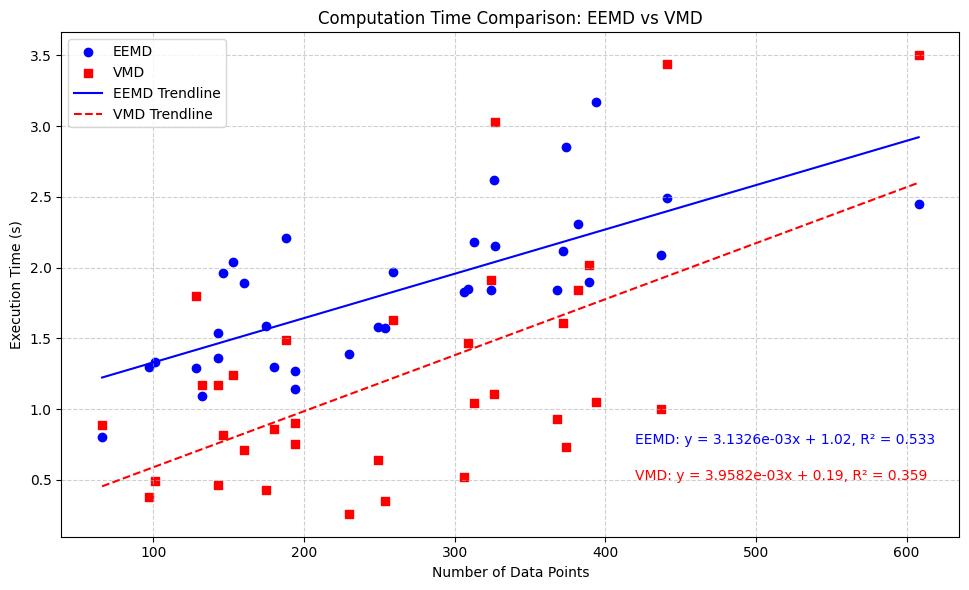

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
data_points = np.array([
    175, 194, 194, 143, 230, 160, 394, 143, 437, 180,
    128, 146, 132, 249, 66,  441, 313, 389, 368, 327,
    188, 309, 372, 374, 326, 259, 608, 153, 306, 324,
    254, 382, 101, 97
])

time_eemd = np.array([
    1.59, 1.14, 1.27, 1.36, 1.39, 1.89, 3.17, 1.54, 2.09, 1.30,
    1.29, 1.96, 1.09, 1.58, 0.80, 2.49, 2.18, 1.90, 1.84, 2.15,
    2.21, 1.85, 2.12, 2.85, 2.62, 1.97, 2.45, 2.04, 1.83, 1.84,
    1.57, 2.31, 1.33, 1.30
])

time_vmd = np.array([
    0.43, 0.90, 0.75, 0.46, 0.26, 0.71, 1.05, 1.17, 1.00, 0.86,
    1.80, 0.82, 1.17, 0.64, 0.89, 3.44, 1.04, 2.02, 0.93, 3.03,
    1.49, 1.47, 1.61, 0.73, 1.11, 1.63, 3.50, 1.24, 0.52, 1.91,
    0.35, 1.84, 0.49, 0.38
])

plt.figure(figsize=(10,6))

# Scatter plot
plt.scatter(data_points, time_eemd, color='blue', marker='o', label='EEMD')
plt.scatter(data_points, time_vmd, color='red', marker='s', label='VMD')

# Fit trendlines (linear regression)
z_eemd = np.polyfit(data_points, time_eemd, 1)
p_eemd = np.poly1d(z_eemd)
z_vmd = np.polyfit(data_points, time_vmd, 1)
p_vmd = np.poly1d(z_vmd)

# Generate smooth x values for plotting the lines
x_range = np.linspace(min(data_points), max(data_points), 200)
plt.plot(x_range, p_eemd(x_range), color='blue', linestyle='-', label='EEMD Trendline')
plt.plot(x_range, p_vmd(x_range), color='red', linestyle='--', label='VMD Trendline')

# --- Compute R² for both regressions ---
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

r2_eemd = r_squared(time_eemd, p_eemd(data_points))
r2_vmd = r_squared(time_vmd, p_vmd(data_points))

# Regression equations with R²
eq_eemd = f"EEMD: y = {z_eemd[0]:.4e}x + {z_eemd[1]:.2f}, R² = {r2_eemd:.3f}"
eq_vmd = f"VMD: y = {z_vmd[0]:.4e}x + {z_vmd[1]:.2f}, R² = {r2_vmd:.3f}"

# Add text to plot (adjust y-coordinates as needed)
plt.text(420, 0.75, eq_eemd, color='blue', fontsize=10)
plt.text(420, 0.5, eq_vmd, color='red', fontsize=10)

# Labels, grid, legend
plt.xlabel("Number of Data Points")
plt.ylabel("Execution Time (s)")
plt.title("Computation Time Comparison: EEMD vs VMD")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# @title
import pandas as pd

file_path ="/content/drive/MyDrive/SG_All_Sites_Summary xx.csv"
data = pd.read_csv(file_path)

df = pd.DataFrame(data)
print(df)


      N  Time_EEMD  Time_VMD  R2_Orig  Mean_Orig  Median_Orig  Peak_Orig  \
0   608       3.24      2.28    0.311     12.989        6.101    150.922   
1   152       1.73      0.81    0.256     13.379        4.360    286.627   
2   306       2.09      1.48    0.585      7.170        2.785     83.364   
3   344       2.27      1.93    0.520     13.002        8.529    153.783   
4   254       2.71      0.32    0.519     41.877       14.590   1427.670   
5   434       2.33      1.09    0.427     43.456       11.435    662.710   
6   406       2.05      0.63    0.112      8.053        6.770    130.145   
7   100       1.22      0.41    0.593      4.913        1.822     40.610   
8    96       1.29      0.22    0.383     65.034       33.110    662.479   
9   440       2.80      2.20    0.364     13.994        6.014    634.692   
10  312       2.32      1.00    0.353     50.299       12.256    886.615   
11  388       2.42      1.39    0.471     46.619        9.372   1336.944   
12  368     


=== Normality Test (Shapiro–Wilk) ===
Mean_diff: W = 0.763, p = 0.0000 → Non-normal
Median_diff: W = 0.723, p = 0.0000 → Non-normal

Wilcoxon signed-rank (Mean): W = 127.000, p = 0.0028

Wilcoxon signed-rank (Median): W = 24.000, p = 0.0000


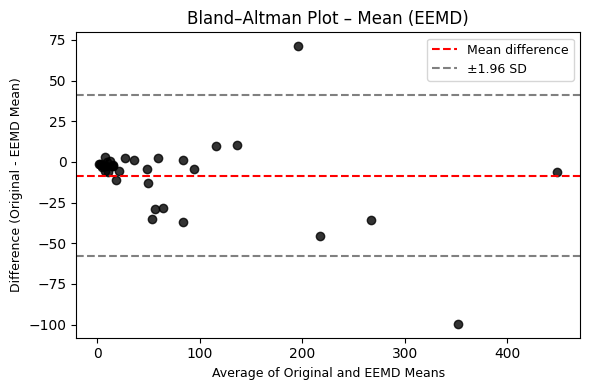


Mean Bias = -8.40, Upper LoA = 40.97, Lower LoA = -57.76


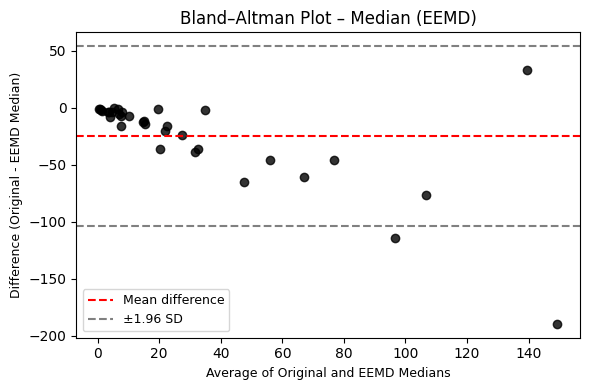


Median Bias = -24.69, Upper LoA = 54.15, Lower LoA = -103.52


In [ ]:
# @title
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- STEP 2 – Normality Tests ----------
alpha = 0.05
print("\n=== Normality Test (Shapiro–Wilk) ===")
for label, diff in {
    "Mean_diff": df["Mean_Orig"] - df["Mean_EEMD"],
    "Median_diff": df["Median_Orig"] - df["Median_EEMD"]
}.items():
    stat, p = stats.shapiro(diff)
    print(f"{label}: W = {stat:.3f}, p = {p:.4f} → {'Normal' if p>alpha else 'Non-normal'}")

# ---------- STEP 3 – Paired Tests ----------
def cohens_d(x, y):
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

def paired_test(x1, x2, label):
    diff = x1 - x2
    normal = stats.shapiro(diff).pvalue > alpha

    if normal:
        t, p = stats.ttest_rel(x1, x2)
        d = cohens_d(x1, x2)
        print(f"\nPaired t-test ({label}): t = {t:.3f}, p = {p:.4f}, Cohen’s d = {d:.3f}")
    else:
        w, p = stats.wilcoxon(x1, x2)
        print(f"\nWilcoxon signed-rank ({label}): W = {w:.3f}, p = {p:.4f}")

# Run tests
paired_test(df["Mean_Orig"], df["Mean_EEMD"], "Mean")
paired_test(df["Median_Orig"], df["Median_EEMD"], "Median")

# ---------- STEP 4 – Simple Bland–Altman Plot ----------
def bland_altman(x1, x2, label, color):
    diff = x1 - x2
    avg = (x1 + x2) / 2
    mean_bias = np.mean(diff)
    sd_diff = np.std(diff, ddof=1)
    upper_loa = mean_bias + 1.96 * sd_diff
    lower_loa = mean_bias - 1.96 * sd_diff

    plt.figure(figsize=(6, 4))
    plt.scatter(avg, diff, color=color, alpha=0.8)
    plt.axhline(mean_bias, color='red', linestyle='--', label='Mean difference')
    plt.axhline(upper_loa, color='gray', linestyle='--', label='±1.96 SD')
    plt.axhline(lower_loa, color='gray', linestyle='--')

    plt.title(f"Bland–Altman Plot – {label} (EEMD)", fontsize=12)
    plt.xlabel(f"Average of Original and EEMD {label}s", fontsize=9)
    plt.ylabel(f"Difference (Original - EEMD {label})", fontsize=9)
    plt.legend(fontsize=9)
    #plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n{label} Bias = {mean_bias:.2f}, Upper LoA = {upper_loa:.2f}, Lower LoA = {lower_loa:.2f}")

# Generate plots
bland_altman(df["Mean_Orig"], df["Mean_EEMD"], "Mean", "black")
bland_altman(df["Median_Orig"], df["Median_EEMD"], "Median", "black")


In [ ]:
# @title
from scipy import stats
import numpy as np
import pandas as pd

# --- Define a reusable test function ---
def paired_test(original, reconstructed, label):
    print(f"\n===== {label.upper()} COMPARISON =====")
    differences = original - reconstructed

    # --- Normality check ---
    stat, p_norm = stats.shapiro(differences)
    print(f"Shapiro–Wilk test p-value: {p_norm:.4f}")
    alpha = 0.05

    if p_norm > alpha:
        print("✅ Normal distribution – paired t-test used.")
        t_stat, p_val = stats.ttest_rel(original, reconstructed)
        print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
        mean_diff = np.mean(differences)
        std_diff = np.std(differences, ddof=1)
        cohens_d = mean_diff / std_diff
        print(f"Cohen’s d = {cohens_d:.3f}")
        if p_val < alpha:
            print("➡️  Significant difference.")
        else:
            print("➡️  No significant difference.")
        # Interpretation of d
        if abs(cohens_d) < 0.3:
            effect = "small"
        elif abs(cohens_d) < 0.6:
            effect = "medium"
        else:
            effect = "large"
        print(f"Effect size: {effect}.")
    else:
        print("⚠️ Non-normal distribution – Wilcoxon signed-rank test used.")
        w_stat, p_val = stats.wilcoxon(original, reconstructed)
        print(f"Wilcoxon signed-rank: W = {w_stat:.3f}, p = {p_val:.4f}")
        n = len(differences)
        z = (w_stat - (n*(n+1))/4) / np.sqrt((n*(n+1)*(2*n+1))/24)
        r = z / np.sqrt(n)
        print(f"Effect size r = {r:.3f}")
        if p_val < alpha:
            print("➡️  Significant difference.")
        else:
            print("➡️  No significant difference.")
        # Interpretation of r
        if abs(r) < 0.3:
            effect = "small"
        elif abs(r) < 0.5:
            effect = "medium"
        else:
            effect = "large"
        print(f"Effect size: {effect}.")

# --- Run for Mean ---
paired_test(df["Mean_Orig"], df["Mean_EEMD"], "Mean")

# --- Run for Median ---
paired_test(df["Median_Orig"], df["Median_EEMD"], "Median")



===== MEAN COMPARISON =====
Shapiro–Wilk test p-value: 0.0000
⚠️ Non-normal distribution – Wilcoxon signed-rank test used.
Wilcoxon signed-rank: W = 127.000, p = 0.0028
Effect size r = -0.500
➡️  Significant difference.
Effect size: medium.

===== MEDIAN COMPARISON =====
Shapiro–Wilk test p-value: 0.0000
⚠️ Non-normal distribution – Wilcoxon signed-rank test used.
Wilcoxon signed-rank: W = 24.000, p = 0.0000
Effect size r = -0.802
➡️  Significant difference.
Effect size: large.


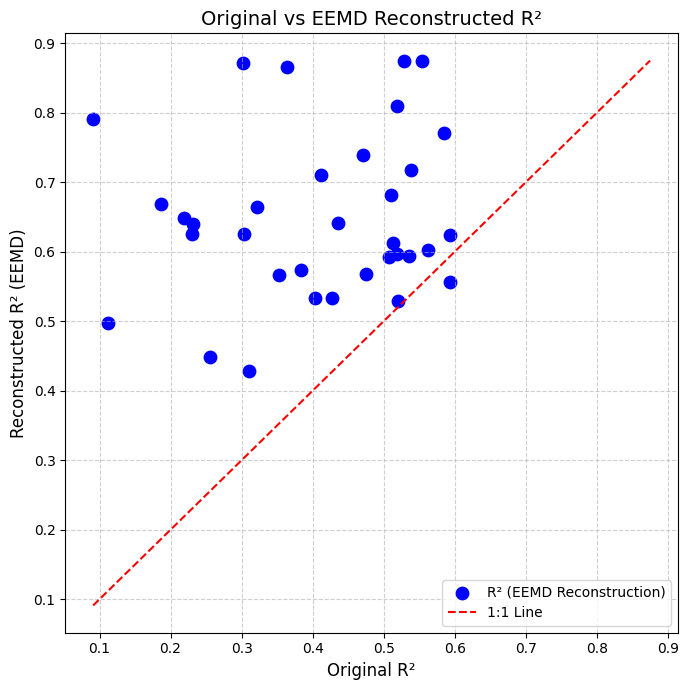

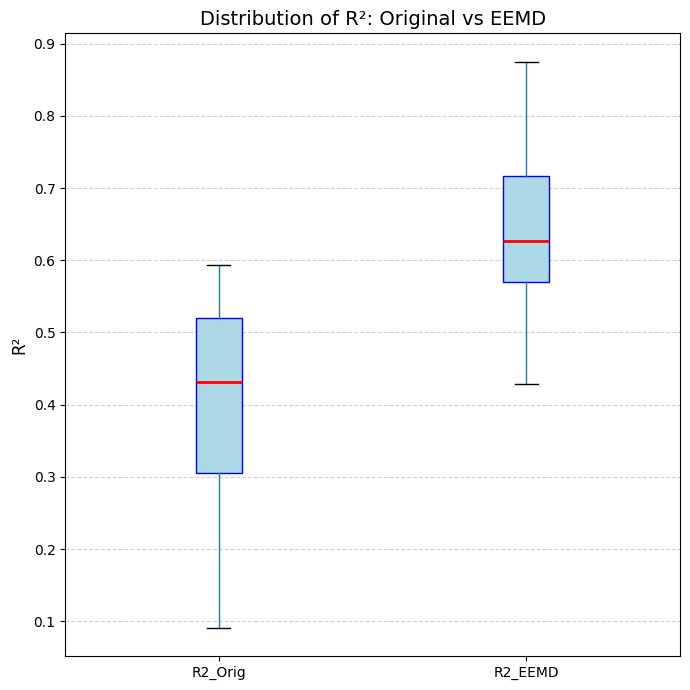

In [ ]:
# @title
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---- STEP 2: Scatter plot (1:1 comparison) ----
plt.figure(figsize=(7,7))
plt.scatter(df["R2_Orig"], df["R2_EEMD"],
            color="blue", s=80, label="R² (EEMD Reconstruction)")

# 1:1 reference line
min_val = min(df["R2_Orig"].min(), df["R2_EEMD"].min())
max_val = max(df["R2_Orig"].max(), df["R2_EEMD"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 Line")

# Labels and formatting
plt.xlabel("Original R²", fontsize=12)
plt.ylabel("Reconstructed R² (EEMD)", fontsize=12)
plt.title("Original vs EEMD Reconstructed R²", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# ---- STEP 3: Boxplot of R² distributions ----
plt.figure(figsize=(7,7))

# Select only the R² columns
r2_data = df[["R2_Orig", "R2_EEMD"]]

# Create boxplot
r2_data.boxplot(grid=False, patch_artist=True,
                boxprops=dict(facecolor="lightblue", color="blue"),
                medianprops=dict(color="red", linewidth=2))

# Labels and formatting
plt.ylabel("R²", fontsize=12)
plt.title("Distribution of R²: Original vs EEMD", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6, axis="y")
plt.tight_layout()
plt.show()

In [ ]:
# @title
import numpy as np
from scipy import stats

# --- EEMD R² data ---
R2_EEMD= df['R2_EEMD']

threshold = 0.6
alpha = 0.05

# --- Step 1: Normality test ---
stat, p_norm = stats.shapiro(R2_EEMD)
print(f"Shapiro–Wilk normality test p = {p_norm:.4f}")

# --- Step 2: Choose test ---
if p_norm > alpha:
    # One-sample t-test (one-tailed)
    t_stat, p_two_tailed = stats.ttest_1samp(R2_EEMD, popmean=threshold)
    p_one_tailed = p_two_tailed / 2  # one-tailed
    print(f"\nOne-sample t-test: t = {t_stat:.3f}, one-tailed p = {p_one_tailed:.4f}")
else:
    # Wilcoxon signed-rank test (one-tailed)
    w_stat, p_two_tailed = stats.wilcoxon(R2_EEMD - threshold)
    p_one_tailed = p_two_tailed / 2  # one-tailed
    print(f"\nOne-sample Wilcoxon: W = {w_stat:.3f}, one-tailed p = {p_one_tailed:.4f}")

# --- Step 3: Summary stats ---
mean_val = np.mean(R2_EEMD)
median_val = np.median(R2_EEMD)
print(f"\nMean R² = {mean_val:.3f}, Median R² = {median_val:.3f}, Threshold = {threshold}")

Shapiro–Wilk normality test p = 0.4660

One-sample t-test: t = 0.829, one-tailed p = 0.2066

Mean R² = 0.622, Median R² = 0.626, Threshold = 0.6



=== Normality Test (Shapiro–Wilk) ===
Mean_diff: W = 0.628, p = 0.0000 → Non-normal
Median_diff: W = 0.560, p = 0.0000 → Non-normal

Wilcoxon signed-rank (Mean): W = 1.000, p = 0.0000

Wilcoxon signed-rank (Median): W = 96.000, p = 0.0003


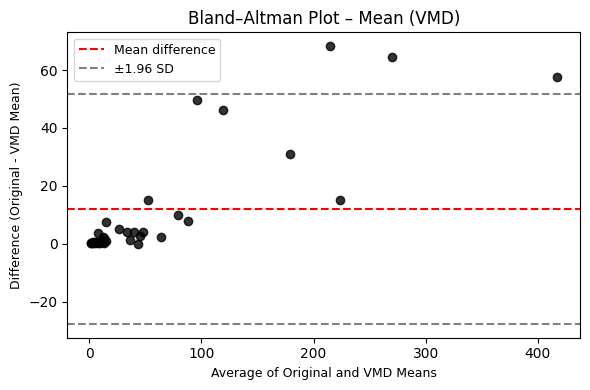


Mean Bias = 12.09, Upper LoA = 51.79, Lower LoA = -27.61


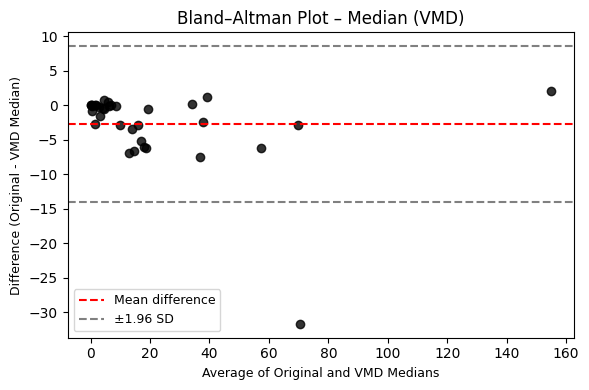


Median Bias = -2.73, Upper LoA = 8.57, Lower LoA = -14.02


In [ ]:
# @title
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- STEP 2 – Normality Tests ----------
alpha = 0.05
print("\n=== Normality Test (Shapiro–Wilk) ===")
for label, diff in {
    "Mean_diff": df["Mean_Orig"] - df["Mean_VMD"],
    "Median_diff": df["Median_Orig"] - df["Median_VMD"]
}.items():
    stat, p = stats.shapiro(diff)
    print(f"{label}: W = {stat:.3f}, p = {p:.4f} → {'Normal' if p>alpha else 'Non-normal'}")

# ---------- STEP 3 – Paired Tests ----------
def cohens_d(x, y):
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

def paired_test(x1, x2, label):
    diff = x1 - x2
    normal = stats.shapiro(diff).pvalue > alpha

    if normal:
        t, p = stats.ttest_rel(x1, x2)
        d = cohens_d(x1, x2)
        print(f"\nPaired t-test ({label}): t = {t:.3f}, p = {p:.4f}, Cohen’s d = {d:.3f}")
    else:
        w, p = stats.wilcoxon(x1, x2)
        print(f"\nWilcoxon signed-rank ({label}): W = {w:.3f}, p = {p:.4f}")

# Run tests
paired_test(df["Mean_Orig"], df["Mean_VMD"], "Mean")
paired_test(df["Median_Orig"], df["Median_VMD"], "Median")

# ---------- STEP 4 – Simple Bland–Altman Plot ----------
def bland_altman(x1, x2, label, color):
    diff = x1 - x2
    avg = (x1 + x2) / 2
    mean_bias = np.mean(diff)
    sd_diff = np.std(diff, ddof=1)
    upper_loa = mean_bias + 1.96 * sd_diff
    lower_loa = mean_bias - 1.96 * sd_diff

    plt.figure(figsize=(6, 4))
    plt.scatter(avg, diff, color=color, alpha=0.8)
    plt.axhline(mean_bias, color='red', linestyle='--', label='Mean difference')
    plt.axhline(upper_loa, color='gray', linestyle='--', label='±1.96 SD')
    plt.axhline(lower_loa, color='gray', linestyle='--')

    plt.title(f"Bland–Altman Plot – {label} (VMD)", fontsize=12)
    plt.xlabel(f"Average of Original and VMD {label}s", fontsize=9)
    plt.ylabel(f"Difference (Original - VMD {label})", fontsize=9)
    plt.legend(fontsize=9)
    #plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n{label} Bias = {mean_bias:.2f}, Upper LoA = {upper_loa:.2f}, Lower LoA = {lower_loa:.2f}")

# Generate plots
bland_altman(df["Mean_Orig"], df["Mean_VMD"], "Mean", "black")
bland_altman(df["Median_Orig"], df["Median_VMD"], "Median", "black")


In [ ]:
# @title
from scipy import stats
import numpy as np
import pandas as pd

# --- Define a reusable test function ---
def paired_test(original, reconstructed, label):
    print(f"\n===== {label.upper()} COMPARISON =====")
    differences = original - reconstructed

    # --- Normality check ---
    stat, p_norm = stats.shapiro(differences)
    print(f"Shapiro–Wilk test p-value: {p_norm:.4f}")
    alpha = 0.05

    if p_norm > alpha:
        print("✅ Normal distribution – paired t-test used.")
        t_stat, p_val = stats.ttest_rel(original, reconstructed)
        print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
        mean_diff = np.mean(differences)
        std_diff = np.std(differences, ddof=1)
        cohens_d = mean_diff / std_diff
        print(f"Cohen’s d = {cohens_d:.3f}")
        if p_val < alpha:
            print("➡️  Significant difference.")
        else:
            print("➡️  No significant difference.")
        # Interpretation of d
        if abs(cohens_d) < 0.3:
            effect = "small"
        elif abs(cohens_d) < 0.6:
            effect = "medium"
        else:
            effect = "large"
        print(f"Effect size: {effect}.")
    else:
        print("⚠️ Non-normal distribution – Wilcoxon signed-rank test used.")
        w_stat, p_val = stats.wilcoxon(original, reconstructed)
        print(f"Wilcoxon signed-rank: W = {w_stat:.3f}, p = {p_val:.4f}")
        n = len(differences)
        z = (w_stat - (n*(n+1))/4) / np.sqrt((n*(n+1)*(2*n+1))/24)
        r = z / np.sqrt(n)
        print(f"Effect size r = {r:.3f}")
        if p_val < alpha:
            print("➡️  Significant difference.")
        else:
            print("➡️  No significant difference.")
        # Interpretation of r
        if abs(r) < 0.3:
            effect = "small"
        elif abs(r) < 0.5:
            effect = "medium"
        else:
            effect = "large"
        print(f"Effect size: {effect}.")

# --- Run for Mean ---
paired_test(df["Mean_Orig"], df["Mean_VMD"], "Mean")

# --- Run for Median ---
paired_test(df["Median_Orig"], df["Median_VMD"], "Median")



===== MEAN COMPARISON =====
Shapiro–Wilk test p-value: 0.0000
⚠️ Non-normal distribution – Wilcoxon signed-rank test used.
Wilcoxon signed-rank: W = 1.000, p = 0.0000
Effect size r = -0.869
➡️  Significant difference.
Effect size: large.

===== MEDIAN COMPARISON =====
Shapiro–Wilk test p-value: 0.0000
⚠️ Non-normal distribution – Wilcoxon signed-rank test used.
Wilcoxon signed-rank: W = 96.000, p = 0.0003
Effect size r = -0.591
➡️  Significant difference.
Effect size: large.


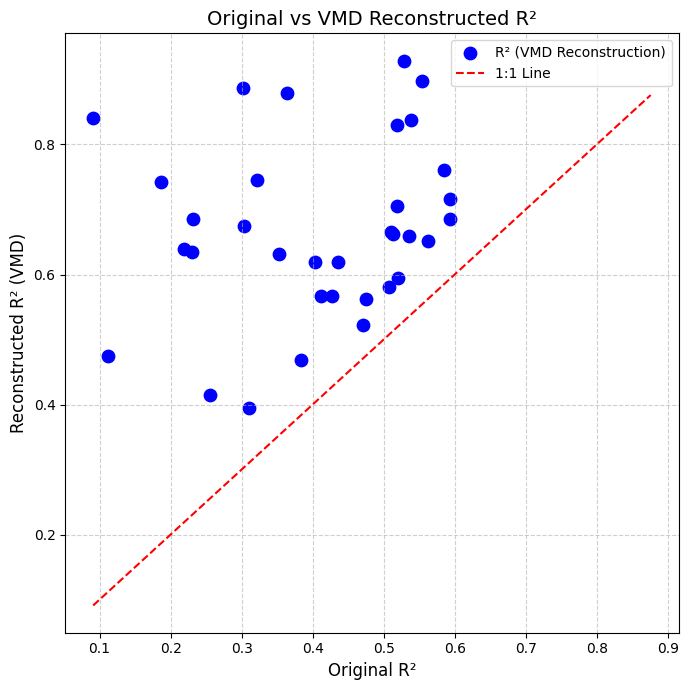

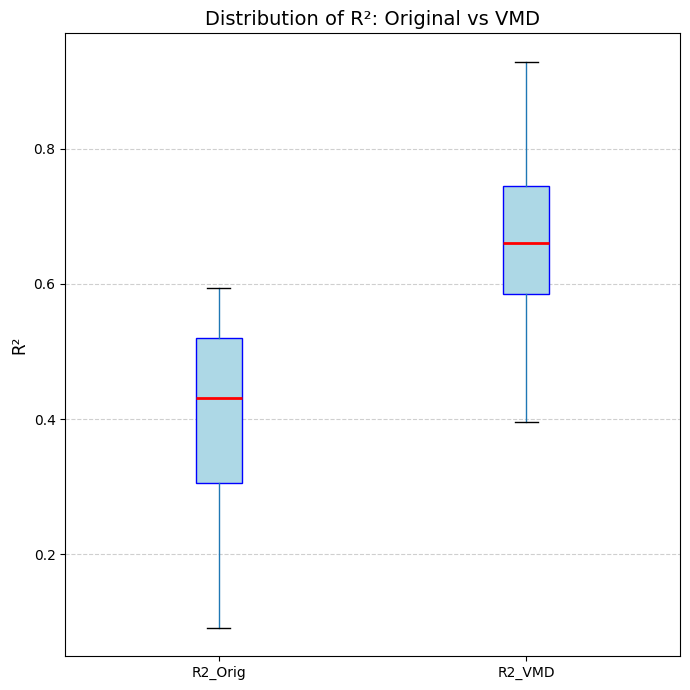

In [ ]:
# @title
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---- STEP 2: Scatter plot (1:1 comparison) ----
plt.figure(figsize=(7,7))
plt.scatter(df["R2_Orig"], df["R2_VMD"],
            color="blue", s=80, label="R² (VMD Reconstruction)")

# 1:1 reference line
min_val = min(df["R2_Orig"].min(), df["R2_VMD"].min())
max_val = max(df["R2_Orig"].max(), df["R2_EEMD"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 Line")

# Labels and formatting
plt.xlabel("Original R²", fontsize=12)
plt.ylabel("Reconstructed R² (VMD)", fontsize=12)
plt.title("Original vs VMD Reconstructed R²", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# ---- STEP 3: Boxplot of R² distributions ----
plt.figure(figsize=(7,7))

# Select only the R² columns
r2_data = df[["R2_Orig", "R2_VMD"]]

# Create boxplot
r2_data.boxplot(grid=False, patch_artist=True,
                boxprops=dict(facecolor="lightblue", color="blue"),
                medianprops=dict(color="red", linewidth=2))

# Labels and formatting
plt.ylabel("R²", fontsize=12)
plt.title("Distribution of R²: Original vs VMD", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6, axis="y")
plt.tight_layout()
plt.show()

In [ ]:
# @title
import numpy as np
from scipy import stats

# --- EEMD R² data ---
R2_VMD= df['R2_VMD']

threshold = 0.6
alpha = 0.05

# --- Step 1: Normality test ---
stat, p_norm = stats.shapiro(R2_VMD)
print(f"Shapiro–Wilk normality test p = {p_norm:.4f}")

# --- Step 2: Choose test ---
if p_norm > alpha:
    # One-sample t-test (one-tailed)
    t_stat, p_two_tailed = stats.ttest_1samp(R2_VMD, popmean=threshold)
    p_one_tailed = p_two_tailed / 2  # one-tailed
    print(f"\nOne-sample t-test: t = {t_stat:.3f}, one-tailed p = {p_one_tailed:.4f}")
else:
    # Wilcoxon signed-rank test (one-tailed)
    w_stat, p_two_tailed = stats.wilcoxon(R2_VMD - threshold)
    p_one_tailed = p_two_tailed / 2  # one-tailed
    print(f"\nOne-sample Wilcoxon: W = {w_stat:.3f}, one-tailed p = {p_one_tailed:.4f}")

# --- Step 3: Summary stats ---
mean_val = np.mean(R2_VMD)
median_val = np.median(R2_VMD)
print(f"\nMean R² = {mean_val:.3f}, Median R² = {median_val:.3f}, Threshold = {threshold}")


Shapiro–Wilk normality test p = 0.5679

One-sample t-test: t = 2.947, one-tailed p = 0.0029

Mean R² = 0.669, Median R² = 0.661, Threshold = 0.6


/tmp/ipykernel_37042/698432333.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_37042/698432333.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_37042/698432333.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_37042/698432333.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_37042/698432333.py:46: FutureWarning: 

P

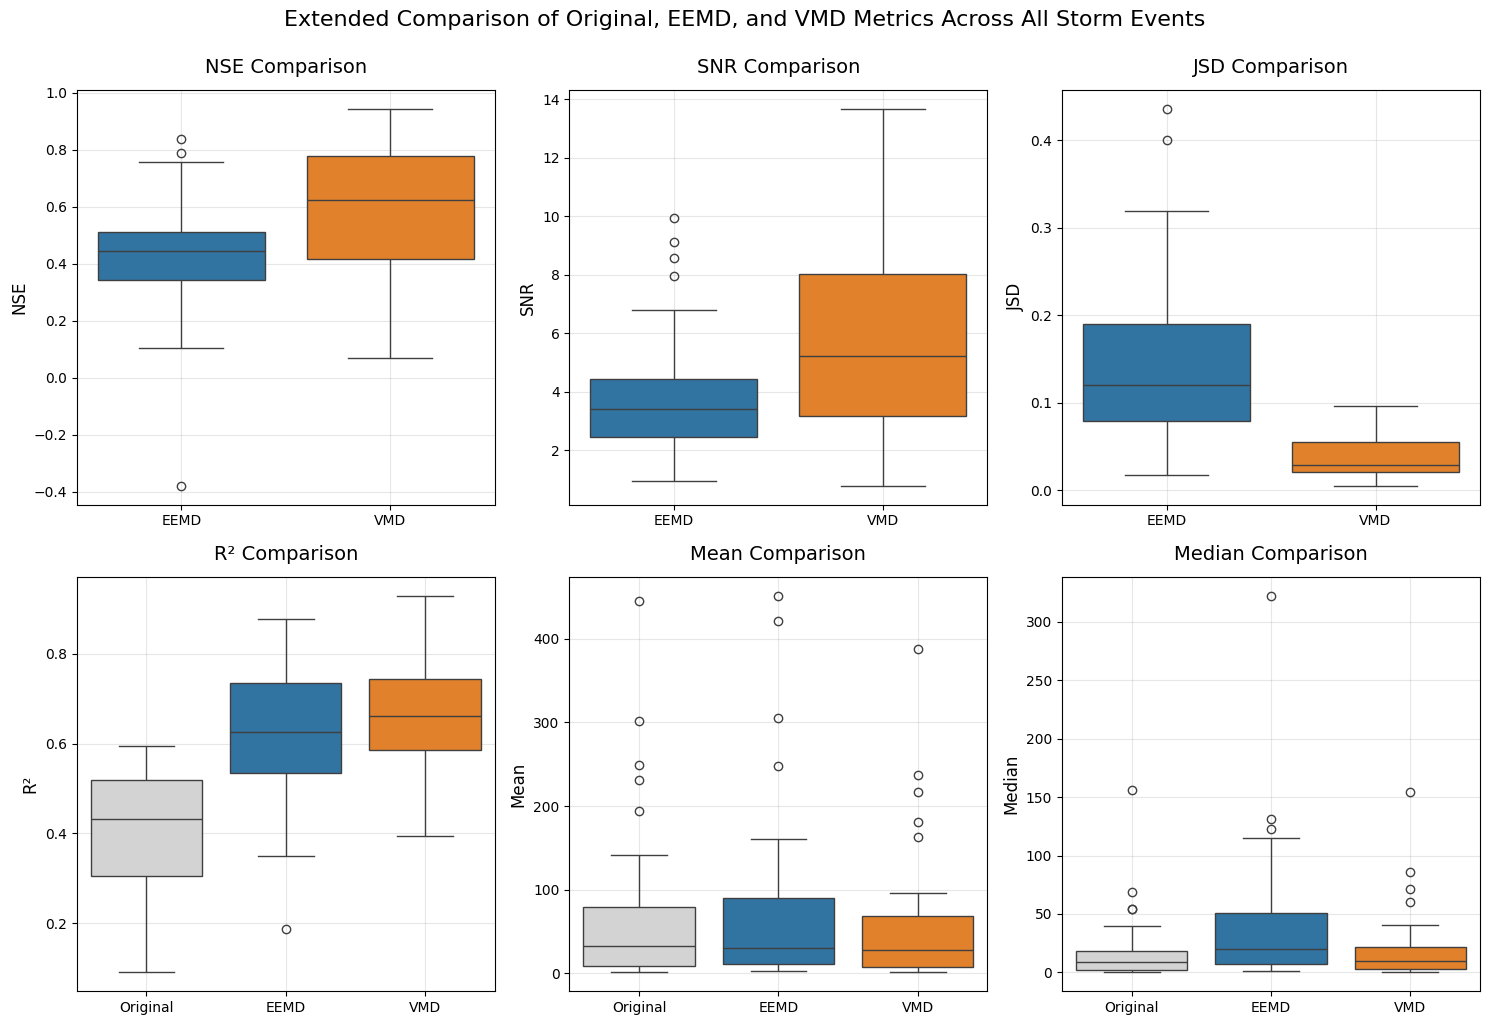

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Create long-format data carefully
long_data = []

# NSE
long_data.append(pd.DataFrame({'Metric': 'NSE', 'Method': 'EEMD', 'Value': df['NSE_EEMD']}))
long_data.append(pd.DataFrame({'Metric': 'NSE', 'Method': 'VMD',  'Value': df['NSE_VMD']}))

# SNR
long_data.append(pd.DataFrame({'Metric': 'SNR', 'Method': 'EEMD', 'Value': df['SNR_EEMD']}))
long_data.append(pd.DataFrame({'Metric': 'SNR', 'Method': 'VMD',  'Value': df['SNR_VMD']}))

# JSD
long_data.append(pd.DataFrame({'Metric': 'JSD', 'Method': 'EEMD', 'Value': df['JSD_EEMD']}))
long_data.append(pd.DataFrame({'Metric': 'JSD', 'Method': 'VMD',  'Value': df['JSD_VMD']}))

# R² (includes Original)
long_data.append(pd.DataFrame({'Metric': 'R²', 'Method': 'Original', 'Value': df['R2_Orig']}))
long_data.append(pd.DataFrame({'Metric': 'R²', 'Method': 'EEMD',    'Value': df['R2_EEMD']}))
long_data.append(pd.DataFrame({'Metric': 'R²', 'Method': 'VMD',     'Value': df['R2_VMD']}))

# Mean (includes Original)
long_data.append(pd.DataFrame({'Metric': 'Mean', 'Method': 'Original', 'Value': df['Mean_Orig']}))
long_data.append(pd.DataFrame({'Metric': 'Mean', 'Method': 'EEMD',    'Value': df['Mean_EEMD']}))
long_data.append(pd.DataFrame({'Metric': 'Mean', 'Method': 'VMD',     'Value': df['Mean_VMD']}))

# Median (includes Original)
long_data.append(pd.DataFrame({'Metric': 'Median', 'Method': 'Original', 'Value': df['Median_Orig']}))
long_data.append(pd.DataFrame({'Metric': 'Median', 'Method': 'EEMD',    'Value': df['Median_EEMD']}))
long_data.append(pd.DataFrame({'Metric': 'Median', 'Method': 'VMD',     'Value': df['Median_VMD']}))

df_long = pd.concat(long_data, ignore_index=True)

# Step 2: Plot - Matrix of boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
palette = {"Original": "lightgray", "EEMD": "#1f77b4", "VMD": "#ff7f0e"}

metrics_to_plot = ['NSE', 'SNR', 'JSD', 'R²', 'Mean', 'Median']

for i, metric in enumerate(metrics_to_plot):
    sns.boxplot(
        data=df_long[df_long["Metric"] == metric],
        x="Method",
        y="Value",
        palette=palette,
        ax=axes[i]
    )

    axes[i].set_title(f"{metric} Comparison", fontsize=14, pad=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(metric if metric != "R²" else "R²", fontsize=12)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Extended Comparison of Original, EEMD, and VMD Metrics Across All Storm Events",
             fontsize=16, y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()